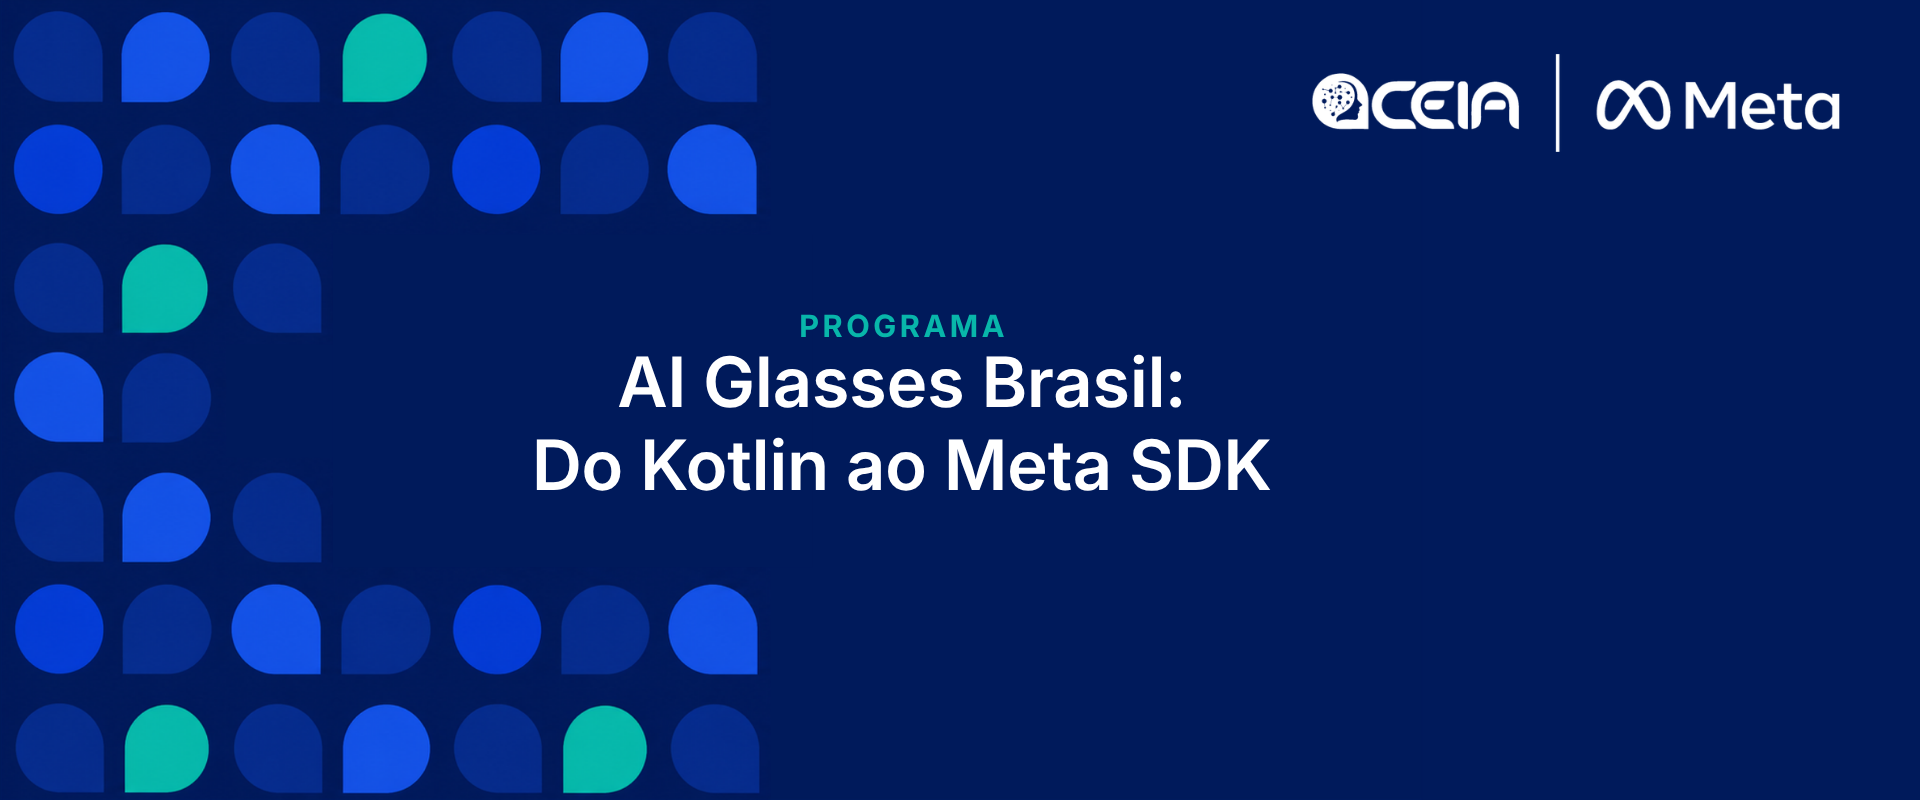

# Notebook de Código — AI Glasses Brasil: Do Kotlin ao Meta SDK

Companion do ebook **AI Glasses Brasil: Do Kotlin ao Meta SDK**, com todo o código-fonte dos dois cursos que preparam as equipes para o hackathon com os óculos Ray-Ban Meta. Cada bloco tem um ID (ex.: `Código 1.2-03`) que corresponde à caixa de referência no ebook, com a seção de origem indicada.

> **Atenção:** a maior parte do código é **Kotlin/Android** e não executa neste notebook — ele serve como ambiente de consulta e cópia para o Android Studio.


# Objetivos de Aprendizagem

Ao final do percurso (Unidades I e II), você será capaz de:

- Programar em **Kotlin** usando coroutines e Flow para dados assíncronos (câmera, áudio, sensores).
- Estruturar um **app Android companion**: ciclo de vida, permissões em runtime e execução em segundo plano com eficiência de energia.
- **Otimizar modelos de IA** para rodar no dispositivo (quantização, formatos, hardware) e aplicá-los a visão computacional e voz (STT/TTS).
- Integrar o app aos **óculos Ray-Ban Meta** com o SDK/DAT: registro, sessão, câmera e áudio via Bluetooth.
- Desenvolver e testar a solução **sem o hardware**, usando o Mock Device Kit.

*(Síntese preliminar dos objetivos dos 15 capítulos — revisar.)*


# Unidade I — Curso de Kotlin/Android


## 1.1 Introdução ao Kotlin


### 1.1.4.2 Passo 2 — Seu primeiro "Olá, mundo"


**Código 1.1-01** · `kotlin` · seção 1.1.4.2 do ebook — A função main é o ponto de entrada: é por aqui que o programa começa.


In [ ]:
// A função main é o ponto de entrada: é por aqui que o programa começa.
fun main() {
    // println imprime uma linha de texto na tela (saída padrão).
    println("Olá, mundo!")
}

### 1.1.4.3 Passo 3 — val, var e tipos


**Código 1.1-02** · `kotlin` · seção 1.1.4.3 do ebook


In [ ]:
val nome = "AKCIT"      // val = read-only: NÃO pode ser reatribuída depois
var contador = 0        // var = mutável: PODE mudar de valor

contador = contador + 1 // OK: contador é var
// nome = "outro"       // ERRO de compilação: nome é val (read-only)

**Código 1.1-03** · `kotlin` · seção 1.1.4.3 do ebook


In [ ]:
val curso: String = "Camp by Meta"  // texto
val ano: Int = 2026                 // número inteiro
val nota: Double = 9.5              // número com casas decimais
val ativo: Boolean = true           // verdadeiro/falso

**Código 1.1-04** · `kotlin` · seção 1.1.4.3 do ebook — texto = null            // ERRO: String comum não aceita nulo · *também exibido no ebook*


In [ ]:
var texto: String = "ok"
// texto = null            // ERRO: String comum não aceita nulo
var talvez: String? = null // OK: o "?" permite ausência de valor

### Código consolidado — Módulo 1.1

Todas as partes do módulo juntas, com imports. Onde rodar: Kotlin Playground (play.kotlinlang.org).


In [ ]:
// Código consolidado do módulo 1.1
// Alvo: Kotlin Playground (play.kotlinlang.org) — cole tudo e rode.
// Cobre 1.1-01 (olá mundo), 1.1-02 (val/var), 1.1-03 (tipos), 1.1-04 (nullable).

// A função main é o ponto de entrada: é por aqui que o programa começa.
fun main() {
    // --- 1.1-01 — Olá, mundo ---
    // println imprime uma linha de texto na tela (saída padrão).
    println("Olá, mundo!")

    // --- 1.1-02 — val (read-only) x var (mutável) ---
    val nome = "AKCIT"      // val = read-only: NÃO pode ser reatribuída depois
    var contador = 0        // var = mutável: PODE mudar de valor

    contador = contador + 1 // OK: contador é var
    // nome = "outro"       // ERRO de compilação: nome é val (read-only)
    println("nome = $nome · contador = $contador")

    // --- 1.1-03 — tipos básicos (declaração explícita) ---
    val curso: String = "Camp by Meta"  // texto
    val ano: Int = 2026                 // número inteiro
    val nota: Double = 9.5              // número com casas decimais
    val ativo: Boolean = true           // verdadeiro/falso
    println("$curso · $ano · $nota · ativo=$ativo")

    // --- 1.1-04 — nulabilidade ---
    var texto: String = "ok"
    // texto = null            // ERRO: String comum não aceita nulo
    var talvez: String? = null // OK: o "?" permite ausência de valor
    println("texto = $texto · talvez = $talvez")

    // Acesso seguro: ?. só chama se não for nulo; ?: dá o valor padrão
    println("tamanho de talvez = ${talvez?.length ?: 0}")
    talvez = "agora tem valor"
    println("tamanho de talvez = ${talvez?.length ?: 0}")
}

### Referências — 1.1

- **Kotlin Documentation — Get started / Home.** Disponível em: https://kotlinlang.org/docs/home.html — porta de entrada da documentação oficial da linguagem, com guias e referência.
- **Kotlin Documentation — Kotlin for Android.** Disponível em: https://kotlinlang.org/docs/android-overview.html — visão geral de por que e como usar Kotlin no Android.
- **Android Developers — Develop Android apps with Kotlin.** Disponível em: https://developer.android.com/kotlin — recursos oficiais do Google sobre Kotlin no Android, incluindo a estratégia Kotlin-first.
- **Android Developers — Install Android Studio.** Disponível em: https://developer.android.com/studio/install — requisitos e passo a passo oficial de instalação do IDE.
- **Android Developers — Android's commitment to Kotlin.** Disponível em: https://developer.android.com/kotlin/first — anúncio oficial do Kotlin como linguagem preferida (contexto histórico de 2019).
- **JetBrains/Kotlin — repositório oficial.** Disponível em: https://github.com/JetBrains/kotlin — código-fonte, releases e histórico da linguagem.


## 1.2 Concorrência com Coroutines e Flow


### 1.2.3.3 Funções suspend


**Código 1.2-01** · `kotlin` · seção 1.2.3.3 do ebook — delay() suspende a coroutine; a thread fica livre nesse meio-tempo


In [ ]:
// delay() suspende a coroutine; a thread fica livre nesse meio-tempo
suspend fun lerSensor(): Float {
    delay(100)      // simula a espera pelo hardware (NÃO bloqueia a thread)
    return 42.0f    // leitura simulada
}

### 1.2.3.4 launch e async: iniciando coroutines


**Código 1.2-02** · `kotlin` · seção 1.2.3.4 do ebook


In [ ]:
scope.launch {
    val leitura = lerSensor()   // pode chamar suspend aqui dentro
    println("Leitura: $leitura")
}

scope.launch {
    // async permite paralelizar dois trabalhos independentes
    val visao = async { rodarModeloDeVisao() }
    val fala  = async { transcreverAudio() }
    combinar(visao.await(), fala.await())   // espera os dois terminarem
}

### 1.2.3.6 Dispatchers: em que thread o código roda


**Código 1.2-03** · `kotlin` · seção 1.2.3.6 do ebook


In [ ]:
suspend fun processarFrame(bytes: ByteArray): Resultado =
    withContext(Dispatchers.Default) {   // muda para as threads de CPU
        decodificarEInferir(bytes)       // trabalho pesado fora da main
    }                                    // ao terminar, volta ao contexto original

### 1.2.4.1 Passo 0 — Dependência


**Código 1.2-04** · `kotlin` · seção 1.2.4.1 do ebook — build.gradle.kts (módulo app)


In [ ]:
// build.gradle.kts (módulo app)
dependencies {
    implementation("org.jetbrains.kotlinx:kotlinx-coroutines-android:1.11.0")
}

### 1.2.4.2 Passo 1 — O sensor simulado


**Código 1.2-05** · `kotlin` · seção 1.2.4.2 do ebook


In [ ]:
import kotlinx.coroutines.delay
import kotlinx.coroutines.flow.Flow
import kotlinx.coroutines.flow.flow
import kotlin.math.sin

// Simula um sensor de luminosidade emitindo ~10 leituras por segundo
fun sensorFlow(): Flow<Float> = flow {
    var t = 0
    while (true) {                      // produtor "infinito", como uma câmera
        emit(sin(t / 10.0).toFloat())   // valor simulado entre -1 e 1
        t++
        delay(100)                      // suspende: nenhuma thread fica presa
    }
}

### 1.2.4.3 Passo 2 — Coletando e transformando


**Código 1.2-06** · `kotlin` · seção 1.2.4.3 do ebook


In [ ]:
import kotlinx.coroutines.flow.filter
import kotlinx.coroutines.flow.map
import kotlinx.coroutines.flow.take
import kotlinx.coroutines.runBlocking

fun main() = runBlocking {      // runBlocking: só para testes fora do Android
    sensorFlow()
        .map { it * 100 }       // converte para uma escala útil
        .filter { it > 0 }      // descarta leituras que não interessam
        .take(20)               // encerra após 20 emissões (didático)
        .collect { println("Leitura: $it") }
}

### 1.2.4.4 Passo 3 — Tirando o trabalho pesado da main thread


**Código 1.2-07** · `kotlin` · seção 1.2.4.4 do ebook


In [ ]:
sensorFlow()
    .map { preProcessar(it) }       // suponha um cálculo pesado aqui
    .flowOn(Dispatchers.Default)    // tudo ACIMA desta linha roda em Default
    .collect { atualizarTela(it) }  // o collect roda no contexto de quem chamou

### 1.2.4.5 Passo 4 — Coletando com segurança na UI do Android


**Código 1.2-08** · `kotlin` · seção 1.2.4.5 do ebook — Dentro de uma Activity (Activity e lifecycle são detalhados no tópico 1.3)


In [ ]:
// Dentro de uma Activity (Activity e lifecycle são detalhados no tópico 1.3)
// Requer androidx.lifecycle:lifecycle-runtime-ktx:2.11.0
lifecycleScope.launch {
    repeatOnLifecycle(Lifecycle.State.STARTED) {   // coleta só com a tela visível
        sensorFlow().collect { valor ->
            textoLeitura.text = "Sensor: %.1f".format(valor)
        }
    }
}


### 1.2.4.6 Passo 5 — E quando a fonte usa callbacks?


**Código 1.2-09** · `kotlin` · seção 1.2.4.6 do ebook


In [ ]:
import kotlinx.coroutines.channels.awaitClose
import kotlinx.coroutines.flow.callbackFlow

// Converte uma API de callback em Flow — padrão que você reutilizará no Módulo 2
fun frameFlow(camera: CameraSimulada): Flow<ByteArray> = callbackFlow {
    val listener = { frame: ByteArray -> trySend(frame) }  // callback vira emissão
    camera.registrarListener(listener)
    awaitClose { camera.removerListener(listener) }        // limpeza garantida no cancelamento
}

### Código consolidado — Módulo 1.2

Todas as partes do módulo juntas, com imports. Onde rodar: Kotlin Playground (play.kotlinlang.org).


In [ ]:
// Código consolidado do módulo 1.2
// Alvo: Kotlin Playground (play.kotlinlang.org) — cole tudo e rode.
// Cobre 1.2-01 (suspend), 1.2-05 (sensorFlow), 1.2-06 (map/filter/take) e 1.2-07 (flowOn).
// O bloco 1.2-08 é Android (lifecycle) e está na consolidada "1.2-Android" logo abaixo.

import kotlinx.coroutines.Dispatchers
import kotlinx.coroutines.delay
import kotlinx.coroutines.flow.Flow
import kotlinx.coroutines.flow.filter
import kotlinx.coroutines.flow.flow
import kotlinx.coroutines.flow.flowOn
import kotlinx.coroutines.flow.map
import kotlinx.coroutines.flow.take
import kotlinx.coroutines.runBlocking
import kotlin.math.sin

// 1.2-01 — função suspend: delay() suspende a coroutine; a thread fica livre
suspend fun lerSensor(): Float {
    delay(100)      // simula a espera pelo hardware (NÃO bloqueia a thread)
    return 42.0f    // leitura simulada
}

// 1.2-05 — Simula um sensor de luminosidade emitindo ~10 leituras por segundo
fun sensorFlow(): Flow<Float> = flow {
    var t = 0
    while (true) {                      // produtor "infinito", como uma câmera
        emit(sin(t / 10.0).toFloat())   // valor simulado entre -1 e 1
        t++
        delay(100)                      // suspende: nenhuma thread fica presa
    }
}

// 1.2-07 — stub do "cálculo pesado" (no app real: decodificar/inferir)
fun preProcessar(valor: Float): Float = valor * 100

fun main() = runBlocking {      // runBlocking: só para testes fora do Android
    // 1.2-01 — chamando uma suspend function
    println("Leitura única: ${lerSensor()}")

    // 1.2-06 — coletando e transformando (take encerra o produtor infinito)
    sensorFlow()
        .map { it * 100 }       // converte para uma escala útil
        .filter { it > 0 }      // descarta leituras que não interessam
        .take(20)               // encerra após 20 emissões (didático)
        .collect { println("Leitura: $it") }

    // 1.2-07 — flowOn: tudo ACIMA da linha roda em Dispatchers.Default;
    // o collect continua no contexto de quem chamou.
    sensorFlow()
        .map { preProcessar(it) }
        .flowOn(Dispatchers.Default)
        .take(5)
        .collect { println("Pré-processado: $it") }
}

### Código consolidado — Módulo 1.2 — Android

Todas as partes do módulo juntas, com imports. Onde rodar: projeto Android (Companion · SensorLifecycleActivity).


In [ ]:
// Código consolidado do módulo 1.2 (parte Android)
// Alvo: projeto Android (Companion) — arquivo cap1_2_coroutines/SensorLifecycleActivity.kt
// Cobre 1.2-05 (sensorFlow) + 1.2-08 (coleta ciente do lifecycle).
// Requer androidx.lifecycle:lifecycle-runtime-ktx:2.11.0 e
// org.jetbrains.kotlinx:kotlinx-coroutines-android:1.11.0

import android.os.Bundle
import android.widget.TextView
import androidx.activity.ComponentActivity
import androidx.lifecycle.Lifecycle
import androidx.lifecycle.lifecycleScope
import androidx.lifecycle.repeatOnLifecycle
import kotlinx.coroutines.delay
import kotlinx.coroutines.flow.Flow
import kotlinx.coroutines.flow.flow
import kotlinx.coroutines.launch
import kotlin.math.sin

// 1.2-05 — sensorFlow (emite ~10 leituras/s), necessário para o 1.2-08
fun sensorFlow(): Flow<Float> = flow {
    var t = 0
    while (true) {
        emit(sin(t / 10.0).toFloat())
        t++
        delay(100)
    }
}

// 1.2-08 — coleta ciente do lifecycle numa Activity (idioma View)
class SensorLifecycleActivity : ComponentActivity() {
    override fun onCreate(savedInstanceState: Bundle?) {
        super.onCreate(savedInstanceState)
        val textoLeitura = TextView(this).apply {
            textSize = 22f
            setPadding(64, 64, 64, 64)
            text = "Sensor: —"
        }
        setContentView(textoLeitura)

        lifecycleScope.launch {
            // repeatOnLifecycle: coleta só com a tela visível (STARTED);
            // cancela em onStop e recomeça em onStart.
            repeatOnLifecycle(Lifecycle.State.STARTED) {
                sensorFlow().collect { valor ->
                    textoLeitura.text = "Sensor: %.1f".format(valor)
                }
            }
        }
    }
}

### Referências — 1.2

- COROUTINES / KOTLIN DOCS. Disponível em: https://kotlinlang.org/docs/coroutines-overview.html. Visão geral oficial de coroutines: suspend, builders e structured concurrency.
- ASYNCHRONOUS FLOW / KOTLIN DOCS. Disponível em: https://kotlinlang.org/docs/flow.html. Guia completo de Flow: cold streams, operadores, `flowOn` e cancelamento.
- KOTLIN COROUTINES ON ANDROID / ANDROID DEVELOPERS. Disponível em: https://developer.android.com/kotlin/coroutines. Coroutines no contexto Android: scopes, dispatchers e integração com o framework.
- KOTLIN FLOWS ON ANDROID / ANDROID DEVELOPERS. Disponível em: https://developer.android.com/kotlin/flow. Flow em apps Android, incluindo coleta segura com o ciclo de vida e StateFlow.
- BEST PRACTICES FOR COROUTINES IN ANDROID / ANDROID DEVELOPERS. Disponível em: https://developer.android.com/kotlin/coroutines/coroutines-best-practices. Regras práticas: injetar dispatchers, evitar GlobalScope e tratar cancelamento.
- KOTLINX.COROUTINES / GITHUB (JETBRAINS). Disponível em: https://github.com/Kotlin/kotlinx.coroutines. Repositório oficial, com changelog e a versão estável atual da biblioteca.


## 1.3 Fundamentos de Android


### 1.3.3.2 Anatomia de um projeto Android (Gradle + Kotlin DSL)


**Código 1.3-01** · `kotlin` · seção 1.3.3.2 do ebook


In [ ]:
android {
    namespace = "com.exemplo.companion" // pacote base do app
    compileSdk = 36

    defaultConfig {
        applicationId = "com.exemplo.companion" // ID único na Play Store/dispositivo
        minSdk = 29
        targetSdk = 36
    }
}

dependencies {
    // O version catalog (libs.versions.toml) resolve os números de versão
    implementation(libs.androidx.lifecycle.viewmodel.compose)
    implementation(libs.androidx.activity.compose)
}

### 1.3.3.3 AndroidManifest: o contrato com o sistema


**Código 1.3-02** · `xml` · seção 1.3.3.3 do ebook


In [ ]:
<manifest xmlns:android="http://schemas.android.com/apk/res/android">
    <application
        android:label="@string/app_name"
        android:theme="@style/Theme.Companion">

        <!-- exported=true: o launcher (outro app) pode iniciá-la -->
        <activity
            android:name=".MainActivity"
            android:exported="true">
            <intent-filter>
                <!-- Este par marca a Activity como ponto de entrada do app -->
                <action android:name="android.intent.action.MAIN" />
                <category android:name="android.intent.category.LAUNCHER" />
            </intent-filter>
        </activity>
    </application>
</manifest>

### 1.3.4.2 Passo 2 — Conferir dependências


**Código 1.3-03** · `kotlin` · seção 1.3.4.2 do ebook — app/build.gradle.kts — bloco dependencies


In [ ]:
// app/build.gradle.kts — bloco dependencies
implementation(libs.androidx.lifecycle.viewmodel.compose)
// artefato androidx.lifecycle:lifecycle-runtime-compose 2.11.0
implementation(libs.androidx.lifecycle.runtime.compose)

### 1.3.4.3 Passo 3 — Modelar o estado da tela


**Código 1.3-04** · `kotlin` · seção 1.3.4.3 do ebook — UiState.kt — o estado da tela em uma data class imutável


In [ ]:
// UiState.kt — o estado da tela em uma data class imutável
data class UiState(
    val connected: Boolean = false,      // já conectou aos óculos?
    val status: String = "Desconectado"  // texto exibido na tela
)

### 1.3.4.4 Passo 4 — Escrever o ViewModel


**Código 1.3-05** · `kotlin` · seção 1.3.4.4 do ebook — MainViewModel.kt


In [ ]:
// MainViewModel.kt
class MainViewModel : ViewModel() {

    // Mutável e privado: só o ViewModel escreve no estado
    private val _uiState = MutableStateFlow(UiState())

    // Exposição somente leitura para a UI observar
    val uiState: StateFlow<UiState> = _uiState.asStateFlow()

    fun onConnectClick() {
        _uiState.update { it.copy(status = "Conectando...") }

        // viewModelScope (tópico 1.2): cancelado junto com o ViewModel
        viewModelScope.launch {
            delay(1_500) // simula o handshake Bluetooth (real no tópico 2.4)
            _uiState.update { it.copy(connected = true, status = "Conectado") }
        }
    }
}

### 1.3.4.5 Passo 5 — Construir a UI em Compose


**Código 1.3-06** · `kotlin` · seção 1.3.4.5 do ebook — MainScreen.kt


In [ ]:
// MainScreen.kt
@Composable
fun MainScreen(viewModel: MainViewModel = viewModel()) {
    // Coleta o StateFlow respeitando o lifecycle: para de coletar
    // quando a tela some, retoma quando volta
    val state by viewModel.uiState.collectAsStateWithLifecycle()

    Column(
        modifier = Modifier.fillMaxSize().padding(24.dp),
        verticalArrangement = Arrangement.Center,
        horizontalAlignment = Alignment.CenterHorizontally
    ) {
        Text(text = state.status) // reage: recompõe a cada novo UiState

        Spacer(Modifier.height(16.dp))

        Button(
            onClick = viewModel::onConnectClick, // evento sobe para o ViewModel
            enabled = !state.connected           // desabilita após conectar
        ) {
            Text("Conectar aos óculos")
        }
    }
}

### 1.3.4.6 Passo 6 — Ligar a Activity


**Código 1.3-07** · `kotlin` · seção 1.3.4.6 do ebook — MainActivity.kt


In [ ]:
// MainActivity.kt
class MainActivity : ComponentActivity() {
    override fun onCreate(savedInstanceState: Bundle?) {
        super.onCreate(savedInstanceState)
        // setContent substitui o setContentView clássico: a UI é Compose
        setContent {
            MaterialTheme {
                MainScreen()
            }
        }
    }
}

### 1.3.4.8 Erro comum 1 — Expor o MutableStateFlow


**Código 1.3-08** · `kotlin` · seção 1.3.4.8 do ebook · *também exibido no ebook*


In [ ]:
val uiState = MutableStateFlow(UiState()) // público e mutável: ruim!

### Código consolidado — Módulo 1.3

Todas as partes do módulo juntas, com imports. Onde rodar: projeto Android (Companion · MainActivity).


In [ ]:
// Código consolidado do módulo 1.3
// Alvo: projeto Android (Companion) — UiState.kt + MainViewModel.kt + MainScreen.kt + MainActivity.kt
// Cobre 1.3-04, 1.3-05, 1.3-06 e 1.3-07. Aqui num único arquivo; no projeto, um arquivo por classe.
// Deps (1.3-03): lifecycle-viewmodel-compose, lifecycle-runtime-compose:2.11.0, activity-compose, material3.

import android.os.Bundle
import androidx.activity.ComponentActivity
import androidx.activity.compose.setContent
import androidx.compose.foundation.layout.Arrangement
import androidx.compose.foundation.layout.Column
import androidx.compose.foundation.layout.Spacer
import androidx.compose.foundation.layout.fillMaxSize
import androidx.compose.foundation.layout.height
import androidx.compose.foundation.layout.padding
import androidx.compose.material3.Button
import androidx.compose.material3.MaterialTheme
import androidx.compose.material3.Text
import androidx.compose.runtime.Composable
import androidx.compose.runtime.getValue
import androidx.compose.ui.Alignment
import androidx.compose.ui.Modifier
import androidx.compose.ui.unit.dp
import androidx.lifecycle.ViewModel
import androidx.lifecycle.compose.collectAsStateWithLifecycle
import androidx.lifecycle.viewModelScope
import androidx.lifecycle.viewmodel.compose.viewModel
import kotlinx.coroutines.delay
import kotlinx.coroutines.flow.MutableStateFlow
import kotlinx.coroutines.flow.StateFlow
import kotlinx.coroutines.flow.asStateFlow
import kotlinx.coroutines.flow.update
import kotlinx.coroutines.launch

// 1.3-04 — UiState.kt — o estado da tela em uma data class imutável
data class UiState(
    val connected: Boolean = false,      // já conectou aos óculos?
    val status: String = "Desconectado"  // texto exibido na tela
)

// 1.3-05 — MainViewModel.kt
class MainViewModel : ViewModel() {

    // Mutável e privado: só o ViewModel escreve no estado
    private val _uiState = MutableStateFlow(UiState())

    // Exposição somente leitura para a UI observar (contraste com o erro do 1.3-08)
    val uiState: StateFlow<UiState> = _uiState.asStateFlow()

    fun onConnectClick() {
        _uiState.update { it.copy(status = "Conectando...") }

        // viewModelScope (tópico 1.2): cancelado junto com o ViewModel
        viewModelScope.launch {
            delay(1_500) // simula o handshake Bluetooth (real no tópico 2.4)
            _uiState.update { it.copy(connected = true, status = "Conectado") }
        }
    }
}

// 1.3-06 — MainScreen.kt
@Composable
fun MainScreen(viewModel: MainViewModel = viewModel()) {
    // Coleta o StateFlow respeitando o lifecycle: para de coletar
    // quando a tela some, retoma quando volta
    val state by viewModel.uiState.collectAsStateWithLifecycle()

    Column(
        modifier = Modifier.fillMaxSize().padding(24.dp),
        verticalArrangement = Arrangement.Center,
        horizontalAlignment = Alignment.CenterHorizontally
    ) {
        Text(text = state.status) // reage: recompõe a cada novo UiState

        Spacer(Modifier.height(16.dp))

        Button(
            onClick = viewModel::onConnectClick, // evento sobe para o ViewModel
            enabled = !state.connected           // desabilita após conectar
        ) {
            Text("Conectar aos óculos")
        }
    }
}

// 1.3-07 — MainActivity.kt
class MainActivity : ComponentActivity() {
    override fun onCreate(savedInstanceState: Bundle?) {
        super.onCreate(savedInstanceState)
        // setContent substitui o setContentView clássico: a UI é Compose
        setContent {
            MaterialTheme {
                MainScreen()
            }
        }
    }
}

### Referências — 1.3

- ACTIVITY LIFECYCLE / ANDROID DEVELOPERS. Disponível em: https://developer.android.com/guide/components/activities/activity-lifecycle. Diagrama oficial e descrição de cada callback do ciclo de vida.
- VIEWMODEL OVERVIEW / ANDROID DEVELOPERS. Disponível em: https://developer.android.com/topic/libraries/architecture/viewmodel. Quando usar ViewModel e como ele sobrevive a mudanças de configuração.
- STATEFLOW AND SHAREDFLOW / ANDROID DEVELOPERS. Disponível em: https://developer.android.com/kotlin/flow/stateflow-and-sharedflow. Padrões de exposição de estado com StateFlow, incluindo coleta lifecycle-aware.
- JETPACK COMPOSE / ANDROID DEVELOPERS. Disponível em: https://developer.android.com/jetpack/compose. Documentação central do Compose: composables, estado e recomposição.
- APP MANIFEST OVERVIEW / ANDROID DEVELOPERS. Disponível em: https://developer.android.com/guide/topics/manifest/manifest-intro. Estrutura e elementos do AndroidManifest.xml.
- CONFIGURE YOUR BUILD / ANDROID DEVELOPERS. Disponível em: https://developer.android.com/build. Gradle no Android: módulos, Kotlin DSL e version catalogs.


## 1.4 Permissões em runtime


### 1.4.4.1 Passo 1 — Declarar no manifesto


**Código 1.4-01** · `xml` · seção 1.4.4.1 do ebook — AndroidManifest.xml, dentro de <manifest>


In [ ]:
<!-- AndroidManifest.xml, dentro de <manifest> -->

<!-- Câmera e microfone -->
<uses-permission android:name="android.permission.CAMERA" />
<uses-permission android:name="android.permission.RECORD_AUDIO" />

<!-- Android 11+: visibilidade do serviço de reconhecimento de fala -->
<queries>
    <intent>
        <action android:name="android.speech.RecognitionService" />
    </intent>
</queries>

<!-- Bluetooth no Android 12+ (API 31+) -->
<uses-permission android:name="android.permission.BLUETOOTH_SCAN"
    android:usesPermissionFlags="neverForLocation" />
<uses-permission android:name="android.permission.BLUETOOTH_CONNECT" />

<!-- Bluetooth legado (Android 11 ou inferior) -->
<uses-permission android:name="android.permission.BLUETOOTH"
    android:maxSdkVersion="30" />
<uses-permission android:name="android.permission.BLUETOOTH_ADMIN"
    android:maxSdkVersion="30" />

### 1.4.4.2 Passo 2 — Função de checagem


**Código 1.4-02** · `kotlin` · seção 1.4.4.2 do ebook


In [ ]:
import android.content.Context
import android.content.pm.PackageManager
import androidx.core.content.ContextCompat

// Extensão simples: a permissão já foi concedida?
fun Context.hasPermission(permission: String): Boolean =
    ContextCompat.checkSelfPermission(this, permission) ==
        PackageManager.PERMISSION_GRANTED

### 1.4.4.3 Passo 3 — Montar a lista de permissões do programa


**Código 1.4-03** · `kotlin` · seção 1.4.4.3 do ebook


In [ ]:
import android.Manifest
import android.os.Build

private val requiredPermissions: List<String> = buildList {
    add(Manifest.permission.CAMERA)
    add(Manifest.permission.RECORD_AUDIO)
    // BLUETOOTH_CONNECT/SCAN só existem no Android 12+;
    // em versões anteriores, as permissões legadas do manifesto bastam.
    if (Build.VERSION.SDK_INT >= Build.VERSION_CODES.S) {
        add(Manifest.permission.BLUETOOTH_CONNECT)
        add(Manifest.permission.BLUETOOTH_SCAN)
    }
}

### 1.4.4.4 Passo 4 — Registrar o launcher e tratar o resultado


**Código 1.4-04** · `kotlin` · seção 1.4.4.4 do ebook


In [ ]:
import androidx.activity.result.contract.ActivityResultContracts
import androidx.activity.ComponentActivity

class MainActivity : ComponentActivity() {

    // Registrado como propriedade: obrigatório antes do estado STARTED
    private val permissionLauncher = registerForActivityResult(
        ActivityResultContracts.RequestMultiplePermissions()
    ) { results: Map<String, Boolean> ->
        val denied = results.filterValues { granted -> !granted }.keys
        when {
            // Tudo concedido: seguir para a conexão com os óculos
            denied.isEmpty() -> startGlassesFlow()

            // Negado E o sistema diz que não vale mais mostrar rationale:
            // negação permanente — só resta mandar para as configurações
            denied.any { !shouldShowRequestPermissionRationale(it) } ->
                showPermanentlyDeniedUi(denied)

            // Negação simples: explicar o impacto e permitir tentar de novo
            else -> showDeniedUi(denied)
        }
    }
}

### 1.4.4.5 Passo 5 — Checar, justificar e pedir


**Código 1.4-05** · `kotlin` · seção 1.4.4.5 do ebook


In [ ]:
private fun ensurePermissions() {
    val missing = requiredPermissions.filterNot { hasPermission(it) }
    when {
        missing.isEmpty() -> startGlassesFlow()

        // Usuário já negou antes: explicar ANTES de pedir de novo
        missing.any { shouldShowRequestPermissionRationale(it) } ->
            showRationaleDialog(
                onAccept = { permissionLauncher.launch(missing.toTypedArray()) }
            )

        else -> permissionLauncher.launch(missing.toTypedArray())
    }
}

### 1.4.4.6 Passo 6 — Tratar a negação permanente


**Código 1.4-06** · `kotlin` · seção 1.4.4.6 do ebook


In [ ]:
import android.content.Intent
import android.net.Uri
import android.provider.Settings

private fun openAppSettings() {
    val intent = Intent(
        Settings.ACTION_APPLICATION_DETAILS_SETTINGS,
        Uri.fromParts("package", packageName, null)
    )
    startActivity(intent)
}

### Código consolidado — Módulo 1.4

Todas as partes do módulo juntas, com imports. Onde rodar: projeto Android (Companion · PermissionsActivity).


In [ ]:
// Código consolidado do módulo 1.4
// Alvo: projeto Android (Companion) — cap1_4_permissoes/PermissionsActivity.kt
// Cobre 1.4-02 (checagem), 1.4-03 (lista), 1.4-04 (launcher), 1.4-05 (pedir) e 1.4-06 (negação permanente).
// As permissões do 1.4-01 continuam no AndroidManifest.xml (célula 1.4-01 acima).

import android.Manifest
import android.content.Context
import android.content.Intent
import android.content.pm.PackageManager
import android.net.Uri
import android.os.Build
import android.os.Bundle
import android.provider.Settings
import android.widget.Toast
import androidx.activity.ComponentActivity
import androidx.activity.compose.setContent
import androidx.activity.result.contract.ActivityResultContracts
import androidx.compose.foundation.layout.Arrangement
import androidx.compose.foundation.layout.Column
import androidx.compose.foundation.layout.Spacer
import androidx.compose.foundation.layout.fillMaxSize
import androidx.compose.foundation.layout.height
import androidx.compose.foundation.layout.padding
import androidx.compose.material3.Button
import androidx.compose.material3.MaterialTheme
import androidx.compose.material3.Text
import androidx.compose.runtime.getValue
import androidx.compose.runtime.mutableStateOf
import androidx.compose.ui.Alignment
import androidx.compose.ui.Modifier
import androidx.compose.ui.unit.dp
import androidx.core.content.ContextCompat

// 1.4-02 — extensão: a permissão já foi concedida?
fun Context.hasPermission(permission: String): Boolean =
    ContextCompat.checkSelfPermission(this, permission) == PackageManager.PERMISSION_GRANTED

// para manter o projeto Compose e não puxar a dependência appcompat.
class PermissionsActivity : ComponentActivity() {

    // 1.4-03 — conjunto de permissões exigidas
    private val requiredPermissions: List<String> = buildList {
        add(Manifest.permission.CAMERA)
        add(Manifest.permission.RECORD_AUDIO)
        if (Build.VERSION.SDK_INT >= Build.VERSION_CODES.S) {
            add(Manifest.permission.BLUETOOTH_CONNECT)
            add(Manifest.permission.BLUETOOTH_SCAN)
        }
    }

    private val status = mutableStateOf("Toque para pedir as permissões")
    private val showSettings = mutableStateOf(false)

    // 1.4-04 — registrar o launcher (antes de STARTED)
    private val permissionLauncher = registerForActivityResult(
        ActivityResultContracts.RequestMultiplePermissions()
    ) { results: Map<String, Boolean> ->
        val denied = results.filterValues { granted -> !granted }.keys
        when {
            denied.isEmpty() -> startGlassesFlow()
            denied.any { !shouldShowRequestPermissionRationale(it) } -> showPermanentlyDeniedUi(denied)
            else -> showDeniedUi(denied)
        }
    }

    // 1.4-05 — decidir o que fazer antes de pedir
    private fun ensurePermissions() {
        val missing = requiredPermissions.filterNot { hasPermission(it) }
        when {
            missing.isEmpty() -> startGlassesFlow()
            missing.any { shouldShowRequestPermissionRationale(it) } ->
                showRationaleDialog(onAccept = { permissionLauncher.launch(missing.toTypedArray()) })
            else -> permissionLauncher.launch(missing.toTypedArray())
        }
    }

    // 1.4-06 — abrir as configurações do app (negação permanente)
    private fun openAppSettings() {
        val intent = Intent(
            Settings.ACTION_APPLICATION_DETAILS_SETTINGS,
            Uri.fromParts("package", packageName, null)
        )
        startActivity(intent)
    }

    // --- stubs de UI (o notebook deixa como "sua UI"): mínimos só p/ validar o fluxo ---
    private fun startGlassesFlow() { status.value = "✅ Todas concedidas — seguiria p/ a conexão"; showSettings.value = false; toast("Concedidas") }
    private fun showDeniedUi(denied: Set<String>) { status.value = "⚠️ Negada (simples): ${denied.joinToString()}"; showSettings.value = false }
    private fun showPermanentlyDeniedUi(denied: Set<String>) { status.value = "⛔ Negada permanentemente: ${denied.joinToString()}"; showSettings.value = true }
    private fun showRationaleDialog(onAccept: () -> Unit) { status.value = "ℹ️ Precisamos de câmera/áudio p/ os óculos"; onAccept() }
    private fun toast(m: String) = Toast.makeText(this, m, Toast.LENGTH_SHORT).show()

    // Ao voltar (ex.: das Configurações), reavalia as permissões (1.4 Passo 6)
    override fun onResume() {
        super.onResume()
        if (requiredPermissions.all { hasPermission(it) }) startGlassesFlow()
    }

    override fun onCreate(savedInstanceState: Bundle?) {
        super.onCreate(savedInstanceState)
        setContent {
            MaterialTheme {
                val s by status
                val settings by showSettings
                Column(
                    modifier = Modifier.fillMaxSize().padding(24.dp),
                    verticalArrangement = Arrangement.Center,
                    horizontalAlignment = Alignment.CenterHorizontally
                ) {
                    Text(s)
                    Spacer(Modifier.height(16.dp))
                    if (settings) {
                        // Negação permanente: launch() é no-op silencioso — só resta as Configurações (1.4 Passo 6)
                        Button(onClick = { openAppSettings() }) { Text("Abrir Configurações") }
                    } else {
                        Button(onClick = { ensurePermissions() }) { Text("Pedir permissões") }
                    }
                }
            }
        }
    }
}

### Referências — 1.4

- PERMISSIONS ON ANDROID / ANDROID DEVELOPERS. Disponível em: https://developer.android.com/guide/topics/permissions/overview — visão geral do modelo de permissões: tipos, grupos e ciclo de vida.
- REQUEST RUNTIME PERMISSIONS / ANDROID DEVELOPERS. Disponível em: https://developer.android.com/training/permissions/requesting — fluxo oficial de solicitação com `ActivityResultContracts`, rationale e tratamento de negação.
- BLUETOOTH PERMISSIONS / ANDROID DEVELOPERS. Disponível em: https://developer.android.com/develop/connectivity/bluetooth/bt-permissions — `BLUETOOTH_CONNECT`/`BLUETOOTH_SCAN`, flag `neverForLocation` e compatibilidade com versões antigas.


## 1.5 Background e eficiência de energia


### 1.5.4.1 Passo 1 — Foreground service para o pipeline de áudio


**Código 1.5-01** · `xml` · seção 1.5.4.1 do ebook — Permissão geral de FGS + permissões por tipo (Android 14+)


In [ ]:
<!-- Permissão geral de FGS + permissões por tipo (Android 14+) -->
<uses-permission android:name="android.permission.FOREGROUND_SERVICE" />
<uses-permission android:name="android.permission.FOREGROUND_SERVICE_MICROPHONE" />
<uses-permission android:name="android.permission.FOREGROUND_SERVICE_CONNECTED_DEVICE" />
<!-- Android 13+: a notificação do FGS exige POST_NOTIFICATIONS concedida em runtime -->
<uses-permission android:name="android.permission.POST_NOTIFICATIONS" />

<application ...>
    <service
        android:name=".AudioPipelineService"
        android:foregroundServiceType="microphone|connectedDevice"
        android:exported="false" />
</application>

**Código 1.5-02** · `kotlin` · seção 1.5.4.1 do ebook


In [ ]:
class AudioPipelineService : Service() {

    override fun onStartCommand(intent: Intent?, flags: Int, startId: Int): Int {
        // Canal de notificação criado no Application (visto no 1.3);
        // POST_NOTIFICATIONS já concedida em runtime (visto no 1.4).
        val notification = NotificationCompat.Builder(this, CHANNEL_ID)
            .setContentTitle("Assistente ativo")
            .setContentText("Ouvindo os óculos…")
            .setSmallIcon(R.drawable.ic_glasses)
            .setOngoing(true) // usuário vê que o serviço está rodando
            .build()

        // Promove o serviço a foreground informando os tipos usados.
        ServiceCompat.startForeground(
            this,
            NOTIFICATION_ID,
            notification,
            ServiceInfo.FOREGROUND_SERVICE_TYPE_MICROPHONE or
                ServiceInfo.FOREGROUND_SERVICE_TYPE_CONNECTED_DEVICE
        )

        // Aqui você inicia a coleta do stream de áudio (tópico 2.6).
        return START_STICKY // se o sistema matar, tenta recriar
    }

    override fun onBind(intent: Intent?): IBinder? = null

    companion object {
        const val CHANNEL_ID = "pipeline"
        const val NOTIFICATION_ID = 1
    }
}

**Código 1.5-03** · `kotlin` · seção 1.5.4.1 do ebook — Em uma Activity visível: · *também exibido no ebook*


In [ ]:
// Em uma Activity visível:
startForegroundService(Intent(this, AudioPipelineService::class.java))

### 1.5.4.2 Passo 2 — WorkManager para o trabalho adiável


**Código 1.5-04** · `kotlin` · seção 1.5.4.2 do ebook · *também exibido no ebook*


In [ ]:
implementation("androidx.work:work-runtime-ktx:2.11.2")

**Código 1.5-05** · `kotlin` · seção 1.5.4.2 do ebook


In [ ]:
class ModelUpdateWorker(
    context: Context,
    params: WorkerParameters
) : CoroutineWorker(context, params) { // roda em coroutine (1.2)

    override suspend fun doWork(): Result {
        return try {
            downloadModel() // suspend fun com a lógica de download
            Result.success()
        } catch (e: IOException) {
            Result.retry() // WorkManager reagenda com backoff
        }
    }
}

// Agendamento com constraints — o sistema escolhe a melhor hora:
val constraints = Constraints.Builder()
    .setRequiresCharging(true)                    // só no carregador
    .setRequiredNetworkType(NetworkType.UNMETERED) // só em rede não tarifada (Wi-Fi)
    .setRequiresBatteryNotLow(true)               // nunca com bateria baixa
    .build()

val request = OneTimeWorkRequestBuilder<ModelUpdateWorker>()
    .setConstraints(constraints)
    .build()

// Nome único evita agendar downloads duplicados:
WorkManager.getInstance(context)
    .enqueueUniqueWork("model-update", ExistingWorkPolicy.KEEP, request)

### 1.5.4.3 Passo 3 — Inferência bursty com limite de taxa e freio térmico


**Código 1.5-06** · `kotlin` · seção 1.5.4.3 do ebook


In [ ]:
class BurstyInferenceEngine(
    private val powerManager: PowerManager,
    private val model: VisionModel
) {
    /** Processa o stream de frames com no máximo 2 inferências/s. */
    suspend fun process(frames: Flow<Frame>) {
        frames
            .sample(500.milliseconds) // descarta frames excedentes (Flow, 1.2)
            .collect { frame ->
                if (isTooHot()) {
                    // Perto do limite térmico: pula o burst e deixa esfriar.
                    delay(5.seconds)
                    return@collect
                }
                model.run(frame) // burst curto; hardware volta a ociosidade depois
            }
    }

    /** headroom ~1.0 = à beira do throttling severo; 0.0 = totalmente frio. */
    private fun isTooHot(): Boolean {
        if (Build.VERSION.SDK_INT < Build.VERSION_CODES.R) return false // getThermalHeadroom exige API 30+
        val headroom = powerManager.getThermalHeadroom(10) // previsão p/ +10 s
        return headroom >= 0.9f // limiar de recuo; ajuste medindo no aparelho
    }
}

### Código consolidado — Módulo 1.5

Todas as partes do módulo juntas, com imports. Onde rodar: projeto Android (Companion · BackgroundActivity).


In [ ]:
// Código consolidado do módulo 1.5
// Alvo: projeto Android (Companion) — AudioPipelineService.kt + ModelUpdateWorker.kt
//        + BurstyInferenceEngine.kt + BackgroundActivity.kt
// Cobre 1.5-02 (FGS), 1.5-03 (start), 1.5-05 (WorkManager) e 1.5-06 (bursty + freio térmico).
// Dep (1.5-04): androidx.work:work-runtime-ktx:2.11.2. O manifesto do 1.5-01 continua acima.
// guarda Build.VERSION.SDK_INT >= 30 (VERSION_CODES.R)
// antes de getThermalHeadroom — a API é 30+ e o minSdk do curso é 29.

import android.app.NotificationChannel
import android.app.NotificationManager
import android.app.Service
import android.content.Intent
import android.content.pm.ServiceInfo
import android.content.Context
import android.os.Build
import android.os.Bundle
import android.os.IBinder
import android.os.PowerManager
import androidx.activity.ComponentActivity
import androidx.activity.compose.setContent
import androidx.compose.foundation.layout.Arrangement
import androidx.compose.foundation.layout.Column
import androidx.compose.foundation.layout.fillMaxSize
import androidx.compose.foundation.layout.padding
import androidx.compose.material3.Button
import androidx.compose.material3.MaterialTheme
import androidx.compose.material3.Text
import androidx.compose.runtime.getValue
import androidx.compose.runtime.mutableStateOf
import androidx.compose.ui.Alignment
import androidx.compose.ui.Modifier
import androidx.compose.ui.unit.dp
import androidx.core.app.NotificationCompat
import androidx.core.app.ServiceCompat
import androidx.work.Constraints
import androidx.work.CoroutineWorker
import androidx.work.ExistingWorkPolicy
import androidx.work.NetworkType
import androidx.work.OneTimeWorkRequestBuilder
import androidx.work.WorkManager
import androidx.work.WorkerParameters
import kotlinx.coroutines.FlowPreview
import kotlinx.coroutines.delay
import kotlinx.coroutines.flow.Flow
import kotlinx.coroutines.flow.sample
import java.io.IOException
import kotlin.time.Duration.Companion.milliseconds
import kotlin.time.Duration.Companion.seconds

// ---------------------------------------------------------------------------
// 1.5-02 — foreground service do pipeline de áudio
// ---------------------------------------------------------------------------
class AudioPipelineService : Service() {

    override fun onStartCommand(intent: Intent?, flags: Int, startId: Int): Int {
        criarCanal() // o material assume o canal criado na Application (1.3); aqui criamos aqui
        val notification = NotificationCompat.Builder(this, CHANNEL_ID)
            .setContentTitle("Assistente ativo")
            .setContentText("Ouvindo os óculos…")
            // material usa R.drawable.ic_glasses (asset do curso); built-in p/ validar sem asset custom
            .setSmallIcon(android.R.drawable.stat_sys_headset)
            .setOngoing(true)
            .build()

        ServiceCompat.startForeground(
            this,
            NOTIFICATION_ID,
            notification,
            ServiceInfo.FOREGROUND_SERVICE_TYPE_MICROPHONE or
                ServiceInfo.FOREGROUND_SERVICE_TYPE_CONNECTED_DEVICE
        )
        // Aqui você iniciaria a coleta do stream de áudio (tópico 2.6).
        return START_STICKY
    }

    override fun onBind(intent: Intent?): IBinder? = null

    private fun criarCanal() {
        val mgr = getSystemService(NotificationManager::class.java)
        if (mgr.getNotificationChannel(CHANNEL_ID) == null) {
            mgr.createNotificationChannel(
                NotificationChannel(CHANNEL_ID, "Pipeline", NotificationManager.IMPORTANCE_LOW)
            )
        }
    }

    companion object {
        const val CHANNEL_ID = "pipeline"
        const val NOTIFICATION_ID = 1
    }
}

// ---------------------------------------------------------------------------
// 1.5-05 — worker de atualização de modelo (roda em coroutine)
// ---------------------------------------------------------------------------
class ModelUpdateWorker(
    context: Context,
    params: WorkerParameters
) : CoroutineWorker(context, params) {

    override suspend fun doWork(): Result {
        return try {
            downloadModel()
            Result.success()
        } catch (e: IOException) {
            Result.retry() // WorkManager reagenda com backoff
        }
    }

    // stub: no material é a lógica real de download do modelo
    private suspend fun downloadModel() {
        delay(1_000)
    }
}

// ---------------------------------------------------------------------------
// 1.5-06 — inferência bursty com limite de taxa e freio térmico
// ---------------------------------------------------------------------------
// Stubs ilustrativos: o material assume estes tipos definidos no app.
class Frame
class VisionModel { fun run(frame: Frame) { /* inferência */ } }

class BurstyInferenceEngine(
    private val powerManager: PowerManager,
    private val model: VisionModel
) {
    /** Processa o stream de frames com no máximo 2 inferências/s. */
    @OptIn(FlowPreview::class) // Flow.sample é @FlowPreview
    suspend fun process(frames: Flow<Frame>) {
        frames
            .sample(500.milliseconds) // descarta frames excedentes (Flow, 1.2)
            .collect { frame ->
                if (isTooHot()) {
                    // Perto do limite térmico: pula o burst e deixa esfriar.
                    delay(5.seconds)
                    return@collect
                }
                model.run(frame) // burst curto; hardware volta a ociosidade depois
            }
    }

    /** headroom ~1.0 = à beira do throttling severo; 0.0 = totalmente frio. */
    private fun isTooHot(): Boolean {
        // getThermalHeadroom exige API 30+ (minSdk do curso = 29).
        if (Build.VERSION.SDK_INT < Build.VERSION_CODES.R) return false
        val headroom = powerManager.getThermalHeadroom(10) // previsão p/ +10 s
        return headroom >= 0.9f // limiar de recuo; ajuste medindo no aparelho
    }
}

// ---------------------------------------------------------------------------
// 1.5 — tela de teste (dispara os 3 mecanismos do capítulo)
// ---------------------------------------------------------------------------
class BackgroundActivity : ComponentActivity() {
    private val status = mutableStateOf("1.5 — background / energia")

    override fun onCreate(savedInstanceState: Bundle?) {
        super.onCreate(savedInstanceState)
        setContent {
            MaterialTheme {
                val s by status
                Column(
                    modifier = Modifier.fillMaxSize().padding(24.dp),
                    verticalArrangement = Arrangement.spacedBy(12.dp),
                    horizontalAlignment = Alignment.CenterHorizontally
                ) {
                    Text(s)
                    Button(onClick = { iniciarServico() }) { Text("Foreground service (1.5-02/03)") }
                    Button(onClick = { agendarWork() }) { Text("Agendar WorkManager (1.5-05)") }
                    Button(onClick = { lerThermal() }) { Text("Ler thermal headroom (1.5-06)") }
                }
            }
        }
    }

    // 1.5-03
    private fun iniciarServico() {
        try {
            startForegroundService(Intent(this, AudioPipelineService::class.java))
            status.value = "Serviço iniciado — veja a notificação 'Assistente ativo'."
        } catch (e: Exception) {
            status.value = "Falha no FGS: ${e.message}\n(conceda RECORD_AUDIO/BLUETOOTH na tela 1.4 antes)"
        }
    }

    // 1.5-05 (enfileiramento)
    private fun agendarWork() {
        val constraints = Constraints.Builder()
            .setRequiresCharging(true)
            .setRequiredNetworkType(NetworkType.UNMETERED)
            .setRequiresBatteryNotLow(true)
            .build()
        val request = OneTimeWorkRequestBuilder<ModelUpdateWorker>()
            .setConstraints(constraints)
            .build()
        WorkManager.getInstance(this)
            .enqueueUniqueWork("model-update", ExistingWorkPolicy.KEEP, request)
        status.value = "WorkManager: 'model-update' enfileirado (roda com carregador + Wi-Fi)."
    }

    // 1.5-06 (parte executável: leitura térmica real no aparelho)
    private fun lerThermal() {
        val pm = getSystemService(PowerManager::class.java)
        val h = if (Build.VERSION.SDK_INT >= Build.VERSION_CODES.R) pm.getThermalHeadroom(10) else Float.NaN
        status.value = "thermal headroom(+10s) = $h\n(NaN = sem info / chamado rápido demais; >=0.9 = quente)"
    }
}

### Referências — 1.5

- FOREGROUND SERVICES / ANDROID DEVELOPERS. Disponível em: https://developer.android.com/develop/background-work/services/foreground-services. Tipos de serviço, permissões por tipo e restrições de start por versão.
- WORKMANAGER / ANDROID DEVELOPERS. Disponível em: https://developer.android.com/topic/libraries/architecture/workmanager. Guia da biblioteca: workers, constraints, trabalho único e periódico.
- BACKGROUND WORK OVERVIEW / ANDROID DEVELOPERS. Disponível em: https://developer.android.com/develop/background-work/background-tasks. Árvore de decisão oficial entre os mecanismos de execução em segundo plano.
- OPTIMIZE FOR DOZE AND APP STANDBY / ANDROID DEVELOPERS. Disponível em: https://developer.android.com/training/monitoring-device-state/doze-standby. Como Doze e App Standby afetam seu app e como testá-los com adb.
- POWERMANAGER / ANDROID DEVELOPERS. Disponível em: https://developer.android.com/reference/android/os/PowerManager. Referência de `getThermalHeadroom` e `addThermalStatusListener`.
- THERMAL API / ANDROID DEVELOPERS. Disponível em: https://developer.android.com/games/optimize/adpf/thermal. Guia de adaptação de carga ao estado térmico (escrito para jogos, vale para inferência).


## 1.6 Edge AI: otimização e redução de modelos


### 1.6.4.4 Passo 4 — Um gostinho do "como" no Android


**Código 1.6-01** · `kotlin` · seção 1.6.4.4 do ebook — build.gradle.kts (módulo) — dependência do runtime LiteRT


In [ ]:
// build.gradle.kts (módulo) — dependência do runtime LiteRT
// implementation("com.google.ai.edge.litert:litert:1.4.2")

// O arquivo classificador_int8.tflite — já quantizado — vai em src/main/assets/
// FileUtil vem da lib de support do LiteRT: adicione a dependência
// (ex.: org.tensorflow:tensorflow-lite-support) OU use o loadModel manual do 1.7-06.
val buffer = FileUtil.loadMappedFile(context, "classificador_int8.tflite")

// O Interpreter executa o modelo; sem delegates, roda na CPU
val interpreter = Interpreter(buffer)

// entrada e saida são buffers com o formato que o modelo espera (ver tópico 1.7)
interpreter.run(entrada, saida)

// Libere o modelo quando não precisar mais — ele ocupa memória nativa
interpreter.close()

### Referências — 1.6

- **LiteRT — Google AI Edge.** Disponível em: https://ai.google.dev/edge/litert. Visão geral do runtime de inferência para mobile/edge (ex-TensorFlow Lite), conversão de modelos e aceleração por delegates.
- **Post-training quantization — Google AI Edge.** Disponível em: https://ai.google.dev/edge/litert/models/post_training_quantization. Guia oficial de quantização pós-treinamento: opções (dynamic range, INT8 completo, FP16) e trade-offs.
- **LiteRT-LM — repositório oficial (google-ai-edge).** Disponível em: https://github.com/google-ai-edge/LiteRT-LM. Runtime e formato para executar modelos de linguagem no ecossistema LiteRT.
- **llama.cpp — repositório oficial (ggml-org).** Disponível em: https://github.com/ggml-org/llama.cpp. Runtime de LLMs quantizados em CPU/GPU de desktop e notebook; documentação do ecossistema GGUF.
- **Especificação GGUF — ggml (ggml-org).** Disponível em: https://github.com/ggml-org/ggml/blob/master/docs/gguf.md. Especificação técnica do formato GGUF (estrutura do arquivo, metadados, tipos de quantização).
- **ONNX.** Disponível em: https://onnx.ai. Especificação do formato aberto e ecossistema de ferramentas de interoperabilidade.
- **ONNX Runtime — Microsoft.** Disponível em: https://onnxruntime.ai. Runtime multiplataforma para modelos ONNX e seus execution providers (CPU, GPU, aceleradores).


## 1.7 Visão computacional: tarefas e como levá-las ao edge


### 1.7.4.1 Etapa 1 — Fine-tuning do YOLO com o dataset da equipe


**Código 1.7-01** · `bash` · seção 1.7.4.1 do ebook — ambiente isolado com uv · *também exibido no ebook*


In [ ]:
# ambiente isolado com uv
uv venv
uv pip install ultralytics

**Código 1.7-02** · `yaml` · seção 1.7.4.1 do ebook — dataset/data.yaml


In [ ]:
# dataset/data.yaml
path: ./dataset
train: images/train   # imagens de treino
val: images/val       # imagens de validação
names:
  0: capacete
  1: colete

**Código 1.7-03** · `python` · seção 1.7.4.1 do ebook


In [ ]:
from ultralytics import YOLO

# Transfer learning: parte do modelo pré-treinado (COCO, 80 classes gerais)
model = YOLO("yolo11n.pt")  # variante nano (YOLO26 é a geração mais recente; yolo11n nano mantido por estabilidade)

# Fine-tuning: re-treina com as classes da equipe
model.train(
    data="dataset/data.yaml",  # nosso dataset (capacete, colete)
    epochs=50,                 # poucas épocas bastam para protótipo
    imgsz=640,                 # resolução de entrada do modelo
)

### 1.7.4.2 Etapa 2 — Quantização e conversão (amarrando com o 1.6)


**Código 1.7-04** · `python` · seção 1.7.4.2 do ebook


In [ ]:
from ultralytics import YOLO

best = YOLO("runs/detect/train/weights/best.pt")

# Converte para TFLite com quantização INT8.
# 'data' fornece imagens de calibração — necessárias na quantização
# pós-treino, como visto no 1.6.
best.export(format="tflite", quantize=8, data="dataset/data.yaml")


### 1.7.4.3 Etapa 3 — Execução no celular com LiteRT (CPU ou GPU)


**Código 1.7-05** · `kotlin` · seção 1.7.4.3 do ebook — build.gradle.kts (módulo app)


In [ ]:
// build.gradle.kts (módulo app)
dependencies {
    implementation("com.google.ai.edge.litert:litert:1.4.2")         // runtime
    implementation("com.google.ai.edge.litert:litert-gpu:1.4.2")     // delegate GPU
    implementation("com.google.ai.edge.litert:litert-gpu-api:1.4.2") // API do delegate
}

**Código 1.7-06** · `kotlin` · seção 1.7.4.3 do ebook — Carrega o .tflite de assets/ como buffer mapeado em memória


In [ ]:
// Carrega o .tflite de assets/ como buffer mapeado em memória
fun loadModel(context: Context, name: String): MappedByteBuffer =
    context.assets.openFd(name).use { fd ->
        FileInputStream(fd.fileDescriptor).channel.map(
            FileChannel.MapMode.READ_ONLY, fd.startOffset, fd.declaredLength
        )
    }

fun createInterpreter(context: Context): Interpreter {
    val model = loadModel(context, "best_int8.tflite")
    val compat = CompatibilityList()

    // Tenta a GPU; se o grafo não for totalmente delegável (ex.: YOLO de detecção
    // com NMS/decode embutidos), cai para a CPU em vez de quebrar.
    if (compat.isDelegateSupportedOnThisDevice) {
        try {
            val options = Interpreter.Options()
                .addDelegate(GpuDelegate(compat.bestOptionsForThisDevice))
            return Interpreter(model, options)
        } catch (e: Exception) {
            // delegate não aplicável a este modelo -> fallback CPU abaixo
        }
    }
    return Interpreter(model, Interpreter.Options().setNumThreads(4))
}


### 1.7.4.4 Etapa 4 — Do frame ao resultado


**Código 1.7-07** · `kotlin` · seção 1.7.4.4 do ebook


In [ ]:
data class Detection(val label: String, val score: Float, val box: RectF)

suspend fun detect(frame: Bitmap): List<Detection> =
    withContext(Dispatchers.Default) {
        val input = preprocess(frame)   // 1. redimensiona p/ 640x640 e normaliza
        interpreter.run(input, output)  // 2. inferência: uma passada do modelo
        postprocess(output)             // 3. decodifica caixas + threshold + NMS
    }

### Código consolidado — Módulos 1.6 e 1.7

Todas as partes do módulo juntas, com imports. Onde rodar: projeto Android (Companion · VisaoActivity).


In [ ]:
// Código consolidado dos módulos 1.6/1.7
// Alvo: projeto Android (Companion) — cap1_7_visao/LiteRtHarness.kt + VisaoActivity.kt
// Cobre 1.6-01 (Interpreter CPU) e 1.7-06 (Interpreter + GpuDelegate com fallback).
// Deps (1.7-05): litert / litert-gpu / litert-gpu-api 1.4.2.
// Assets esperados em app/src/main/assets/: "classificador_int8.tflite" (1.6) e "best_int8.tflite" (1.7).
//
// try/catch no addDelegate(GpuDelegate) com FALLBACK CPU —
// o grafo YOLO de detecção (NMS/decode embutidos) não é 100% delegável e quebraria sem isso.
// Nota: o material usa FileUtil.loadMappedFile, que exige a lib de support do
// LiteRT (não listada nas dependências); aqui usamos o loader manual loadModel() do 1.7-06.

import android.os.Bundle
import android.content.Context
import androidx.activity.ComponentActivity
import androidx.activity.compose.setContent
import androidx.compose.foundation.layout.Arrangement
import androidx.compose.foundation.layout.Column
import androidx.compose.foundation.layout.fillMaxSize
import androidx.compose.foundation.layout.padding
import androidx.compose.material3.Button
import androidx.compose.material3.MaterialTheme
import androidx.compose.material3.Text
import androidx.compose.runtime.getValue
import androidx.compose.runtime.mutableStateOf
import androidx.compose.ui.Alignment
import androidx.compose.ui.Modifier
import androidx.compose.ui.unit.dp
import org.tensorflow.lite.Interpreter
import org.tensorflow.lite.Tensor
import org.tensorflow.lite.gpu.CompatibilityList
import org.tensorflow.lite.gpu.GpuDelegate
import java.io.FileInputStream
import java.nio.ByteBuffer
import java.nio.ByteOrder
import java.nio.MappedByteBuffer
import java.nio.channels.FileChannel

// 1.7-06 — carrega o .tflite de assets/ como buffer mapeado em memória
fun loadModel(context: Context, name: String): MappedByteBuffer =
    context.assets.openFd(name).use { fd ->
        FileInputStream(fd.fileDescriptor).channel.map(
            FileChannel.MapMode.READ_ONLY, fd.startOffset, fd.declaredLength
        )
    }

// Backend realmente usado na última chamada de createInterpreter (GPU ou CPU pós-fallback)
var ultimoDelegate: String = "?"
    private set

// 1.7-06 — cria o Interpreter com delegate GPU e FALLBACK CPU multi-thread
fun createInterpreter(context: Context): Interpreter {
    val model = loadModel(context, "best_int8.tflite")
    val compat = CompatibilityList()

    // Tenta a GPU; se o grafo não for totalmente delegável (ex.: YOLO de detecção
    // com NMS/decode embutidos), cai para a CPU em vez de quebrar.
    if (compat.isDelegateSupportedOnThisDevice) {
        try {
            val options = Interpreter.Options()
                .addDelegate(GpuDelegate(compat.bestOptionsForThisDevice))
            val interpreter = Interpreter(model, options)
            ultimoDelegate = "GPU"
            return interpreter
        } catch (e: Exception) {
            // delegate não aplicável a este modelo -> fallback CPU abaixo
        }
    }
    ultimoDelegate = "CPU(4t)"
    return Interpreter(model, Interpreter.Options().setNumThreads(4))
}

// buffer de zeros no tamanho EXATO do tensor (numBytes cobre float32/int8/etc.)
private fun bufFor(t: Tensor): ByteBuffer =
    ByteBuffer.allocateDirect(t.numBytes()).order(ByteOrder.nativeOrder())

// Caminho 1.7 (Interpreter + GpuDelegate): carrega, roda 1x, reporta delegate/shapes.
fun smokeTest17(context: Context): String {
    val interp = createInterpreter(context)
    try {
        val inT = interp.getInputTensor(0)
        val outT = interp.getOutputTensor(0)
        interp.run(bufFor(inT), bufFor(outT))
        return "1.7 OK — delegate=$ultimoDelegate · in=${inT.shape().joinToString("x")}(${inT.dataType()}) · out=${outT.shape().joinToString("x")}"
    } finally {
        interp.close()
    }
}

// Caminho 1.6-01 (Interpreter CPU-only): Interpreter(buffer) + run + close.
fun smokeTest16(context: Context): String {
    val interp = Interpreter(loadModel(context, "classificador_int8.tflite"))
    try {
        val inT = interp.getInputTensor(0)
        val outT = interp.getOutputTensor(0)
        interp.run(bufFor(inT), bufFor(outT))
        return "1.6 OK — CPU · in=${inT.shape().joinToString("x")}(${inT.dataType()}) · out=${outT.shape().joinToString("x")}"
    } finally {
        interp.close()
    }
}

// 1.6/1.7 — tela de teste do LiteRT (Interpreter CPU e Interpreter + GpuDelegate)
class VisaoActivity : ComponentActivity() {
    private val status = mutableStateOf("1.6/1.7 — LiteRT (toque para carregar + inferir)")

    override fun onCreate(savedInstanceState: Bundle?) {
        super.onCreate(savedInstanceState)
        setContent {
            MaterialTheme {
                val s by status
                Column(
                    modifier = Modifier.fillMaxSize().padding(24.dp),
                    verticalArrangement = Arrangement.spacedBy(12.dp),
                    horizontalAlignment = Alignment.CenterHorizontally
                ) {
                    Text(s)
                    Button(onClick = {
                        status.value = try { smokeTest16(this@VisaoActivity) }
                        catch (e: Throwable) { "1.6 FALHOU: ${e.message}" }
                    }) { Text("1.6 — Interpreter (CPU)") }
                    Button(onClick = {
                        status.value = try { smokeTest17(this@VisaoActivity) }
                        catch (e: Throwable) { "1.7 FALHOU: ${e.message}" }
                    }) { Text("1.7 — Interpreter + GpuDelegate") }
                }
            }
        }
    }
}

### Referências — 1.7

- ML KIT / GOOGLE. Disponível em: https://developers.google.com/ml-kit. Catálogo das APIs prontas de visão on-device (OCR, detecção, landmarks, image labeling).
- LITERT / GOOGLE AI EDGE. Disponível em: https://ai.google.dev/edge/litert. Documentação do runtime de inferência: guia Android, formatos e otimização.
- GPU ACCELERATION DELEGATE / GOOGLE AI EDGE. Disponível em: https://ai.google.dev/edge/litert/android/gpu. Como habilitar o delegate GPU com a Interpreter API e as dependências necessárias.
- MEDIAPIPE SOLUTIONS / GOOGLE AI EDGE. Disponível em: https://ai.google.dev/edge/mediapipe/solutions/guide. Pipelines prontos de visão (detecção, segmentação, landmarks de mãos/rosto/pose).
- ULTRALYTICS (repositório oficial). Disponível em: https://github.com/ultralytics/ultralytics. Código e documentação de treino, fine-tuning e exportação dos modelos YOLO.
- EXPORT YOLO TO TFLITE / ULTRALYTICS DOCS. Disponível em: https://docs.ultralytics.com/integrations/tflite. Guia oficial de exportação para TFLite, incluindo quantização INT8 com dados de calibração.


## 1.8 Voz no dispositivo: STT e TTS


### 1.8.4.1 Passo 0 — Permissão de microfone


**Código 1.8-01** · `xml` · seção 1.8.4.1 do ebook · *também exibido no ebook*


In [ ]:
<uses-permission android:name="android.permission.RECORD_AUDIO" />

### 1.8.4.2 STT com a API nativa: SpeechRecognizer


**Código 1.8-02** · `kotlin` · seção 1.8.4.2 do ebook


In [ ]:
class SttManager(private val context: Context) {

    private var recognizer: SpeechRecognizer? = null

    fun start(onText: (String) -> Unit, onError: (Int) -> Unit) {
        // 1) Existe serviço de reconhecimento neste aparelho?
        if (!SpeechRecognizer.isRecognitionAvailable(context)) {
            onError(SpeechRecognizer.ERROR_CLIENT); return
        }

        // 2) Criar o recognizer — sempre na main thread
        recognizer = SpeechRecognizer.createSpeechRecognizer(context).apply {
            setRecognitionListener(object : RecognitionListener {
                override fun onResults(results: Bundle) {
                    // Hipóteses ordenadas da mais provável para a menos
                    results.getStringArrayList(SpeechRecognizer.RESULTS_RECOGNITION)
                        ?.firstOrNull()?.let(onText)
                }
                override fun onPartialResults(partial: Bundle) {
                    // Transcrição parcial — útil para feedback em "streaming"
                }
                override fun onError(error: Int) = onError(error)
                // Demais callbacks vazios por brevidade:
                override fun onReadyForSpeech(params: Bundle?) {}
                override fun onBeginningOfSpeech() {}
                override fun onRmsChanged(rmsdB: Float) {}
                override fun onBufferReceived(buffer: ByteArray?) {}
                override fun onEndOfSpeech() {}
                override fun onEvent(eventType: Int, params: Bundle?) {}
            })
        }

        // 3) Configurar o pedido de reconhecimento e iniciar a escuta
        val intent = Intent(RecognizerIntent.ACTION_RECOGNIZE_SPEECH).apply {
            putExtra(RecognizerIntent.EXTRA_LANGUAGE_MODEL,
                     RecognizerIntent.LANGUAGE_MODEL_FREE_FORM)
            putExtra(RecognizerIntent.EXTRA_LANGUAGE, "pt-BR")
            putExtra(RecognizerIntent.EXTRA_PARTIAL_RESULTS, true)
            // API 23+: PREFERIR reconhecimento offline (não é garantia)
            putExtra(RecognizerIntent.EXTRA_PREFER_OFFLINE, true)
        }
        recognizer?.startListening(intent)
    }

    fun stop() {
        recognizer?.destroy()   // libera o serviço — chame no onDestroy()
        recognizer = null
    }
}

### 1.8.4.3 TTS com a API nativa: TextToSpeech


**Código 1.8-03** · `kotlin` · seção 1.8.4.3 do ebook


In [ ]:
class TtsManager(context: Context) : TextToSpeech.OnInitListener {

    private val tts = TextToSpeech(context, this)  // init ASSÍNCRONO
    private var ready = false

    override fun onInit(status: Int) {
        if (status == TextToSpeech.SUCCESS) {
            val result = tts.setLanguage(Locale.forLanguageTag("pt-BR"))
            ready = result != TextToSpeech.LANG_MISSING_DATA &&
                    result != TextToSpeech.LANG_NOT_SUPPORTED
        }
    }

    fun speak(text: String) {
        if (!ready) return  // erro comum: falar antes do onInit concluir
        // QUEUE_FLUSH descarta falas pendentes; QUEUE_ADD enfileira
        tts.speak(text, TextToSpeech.QUEUE_FLUSH, null, "utterance-1")
    }

    fun shutdown() = tts.shutdown()  // libere no onDestroy()
}

### 1.8.4.4 STT on-device com Whisper tiny (whisper.cpp)


**Código 1.8-04** · `kotlin` · seção 1.8.4.4 do ebook — 1) Captura: PCM 16 kHz, mono, 16 bits — o formato que o Whisper espera


In [ ]:
// 1) Captura: PCM 16 kHz, mono, 16 bits — o formato que o Whisper espera
val bufferSize = AudioRecord.getMinBufferSize(
    16_000, AudioFormat.CHANNEL_IN_MONO, AudioFormat.ENCODING_PCM_16BIT)
val record = AudioRecord(MediaRecorder.AudioSource.MIC, 16_000,
    AudioFormat.CHANNEL_IN_MONO, AudioFormat.ENCODING_PCM_16BIT, bufferSize)
// Leia as amostras em loop dentro de uma coroutine (Dispatchers.IO, como no 1.2),
// acumulando a fala até o usuário soltar o botão (push-to-talk) ou o VAD indicar fim.

**Código 1.8-05** · `kotlin` · seção 1.8.4.4 do ebook — 2) e 3) Carga do modelo e transcrição — API do binding do exemplo oficial


In [ ]:
// 2) e 3) Carga do modelo e transcrição — API do binding do exemplo oficial
// depende do módulo JNI do whisper.cpp compilado no projeto
// ATENÇÃO: compile a lib nativa em -O3 (release); em debug a inferência fica ~33x mais lenta sem essa flag

val whisper = WhisperContext.createContextFromFile(modelPath) // ggml-tiny(.q?).bin

suspend fun transcribe(samples: FloatArray): String =
    withContext(Dispatchers.Default) {   // inferência pesada: nunca na main thread
        whisper.transcribeData(samples)
    }

### 1.8.4.5 TTS on-device com Piper


**Código 1.8-06** · `kotlin` · seção 1.8.4.5 do ebook — depende da dependência sherpa-onnx e de uma voz pt-BR do Piper


In [ ]:
// depende da dependência sherpa-onnx e de uma voz pt-BR do Piper
val tts = OfflineTts(config = ttsConfig)  // config aponta para o .onnx da voz
val audio = tts.generate(text = "Certo! Encontrei três resultados.", sid = 0, speed = 1.0f)
// audio.samples (FloatArray) → reproduzir com AudioTrack

### Código consolidado — Módulo 1.8

Todas as partes do módulo juntas, com imports. Onde rodar: projeto Android (Companion · VozActivity).


In [ ]:
// Código consolidado do módulo 1.8
// Alvo: projeto Android (Companion) — cap1_8_voz/SttManager.kt + TtsManager.kt + VozActivity.kt
// Cobre 1.8-02 (STT nativo) e 1.8-03 (TTS nativo). Os blocos 1.8-04/05/06 (Whisper/Piper) ficam
// fora desta consolidada: dependem de bindings nativos (whisper.cpp / sherpa-onnx) fora do Companion.
// Manifest (1.8-01): <uses-permission android:name="android.permission.RECORD_AUDIO" /> e, no
// Android 11+, <queries><intent><action android:name="android.speech.RecognitionService"/></intent></queries>.

import android.content.Context
import android.content.Intent
import android.os.Bundle
import android.speech.RecognitionListener
import android.speech.RecognizerIntent
import android.speech.SpeechRecognizer
import android.speech.tts.TextToSpeech
import androidx.activity.ComponentActivity
import androidx.activity.compose.setContent
import androidx.compose.foundation.layout.Arrangement
import androidx.compose.foundation.layout.Column
import androidx.compose.foundation.layout.fillMaxSize
import androidx.compose.foundation.layout.padding
import androidx.compose.material3.Button
import androidx.compose.material3.MaterialTheme
import androidx.compose.material3.Text
import androidx.compose.runtime.getValue
import androidx.compose.runtime.mutableStateOf
import androidx.compose.ui.Alignment
import androidx.compose.ui.Modifier
import androidx.compose.ui.unit.dp
import java.util.Locale

// ---------------------------------------------------------------------------
// 1.8-02 — STT com SpeechRecognizer (nativo Android)
// ---------------------------------------------------------------------------
class SttManager(private val context: Context) {

    private var recognizer: SpeechRecognizer? = null

    fun start(onText: (String) -> Unit, onError: (Int) -> Unit) {
        // 1) Existe serviço de reconhecimento neste aparelho?
        if (!SpeechRecognizer.isRecognitionAvailable(context)) {
            onError(SpeechRecognizer.ERROR_CLIENT); return
        }

        // 2) Criar o recognizer — sempre na main thread
        recognizer = SpeechRecognizer.createSpeechRecognizer(context).apply {
            setRecognitionListener(object : RecognitionListener {
                override fun onResults(results: Bundle) {
                    results.getStringArrayList(SpeechRecognizer.RESULTS_RECOGNITION)
                        ?.firstOrNull()?.let(onText)
                }
                override fun onPartialResults(partial: Bundle) {}
                override fun onError(error: Int) = onError(error)
                override fun onReadyForSpeech(params: Bundle?) {}
                override fun onBeginningOfSpeech() {}
                override fun onRmsChanged(rmsdB: Float) {}
                override fun onBufferReceived(buffer: ByteArray?) {}
                override fun onEndOfSpeech() {}
                override fun onEvent(eventType: Int, params: Bundle?) {}
            })
        }

        // 3) Configurar o pedido e iniciar a escuta
        val intent = Intent(RecognizerIntent.ACTION_RECOGNIZE_SPEECH).apply {
            putExtra(RecognizerIntent.EXTRA_LANGUAGE_MODEL, RecognizerIntent.LANGUAGE_MODEL_FREE_FORM)
            putExtra(RecognizerIntent.EXTRA_LANGUAGE, "pt-BR")
            putExtra(RecognizerIntent.EXTRA_PARTIAL_RESULTS, true)
            putExtra(RecognizerIntent.EXTRA_PREFER_OFFLINE, true)
        }
        recognizer?.startListening(intent)
    }

    fun stop() {
        recognizer?.destroy()
        recognizer = null
    }
}

// ---------------------------------------------------------------------------
// 1.8-03 — TTS com TextToSpeech (nativo Android)
// ---------------------------------------------------------------------------
class TtsManager(context: Context) : TextToSpeech.OnInitListener {

    private val tts = TextToSpeech(context, this)  // init ASSÍNCRONO
    private var ready = false

    override fun onInit(status: Int) {
        if (status == TextToSpeech.SUCCESS) {
            val result = tts.setLanguage(Locale.forLanguageTag("pt-BR"))
            ready = result != TextToSpeech.LANG_MISSING_DATA &&
                    result != TextToSpeech.LANG_NOT_SUPPORTED
        }
    }

    fun isReady() = ready

    fun speak(text: String) {
        if (!ready) return
        tts.speak(text, TextToSpeech.QUEUE_FLUSH, null, "utterance-1")
    }

    fun shutdown() = tts.shutdown()
}

// ---------------------------------------------------------------------------
// 1.8 — tela de teste de voz (SpeechRecognizer + TextToSpeech nativos)
// ---------------------------------------------------------------------------
class VozActivity : ComponentActivity() {
    private lateinit var tts: TtsManager
    private lateinit var stt: SttManager
    private val status = mutableStateOf("1.8 — voz (SpeechRecognizer + TextToSpeech)")

    override fun onCreate(savedInstanceState: Bundle?) {
        super.onCreate(savedInstanceState)
        tts = TtsManager(this)
        stt = SttManager(this)
        setContent {
            MaterialTheme {
                val s by status
                Column(
                    modifier = Modifier.fillMaxSize().padding(24.dp),
                    verticalArrangement = Arrangement.spacedBy(12.dp),
                    horizontalAlignment = Alignment.CenterHorizontally
                ) {
                    Text(s)
                    Button(onClick = {
                        if (tts.isReady()) {
                            tts.speak("Olá! Teste de voz do AKCIT Camp.")
                            status.value = "TTS: falando…"
                        } else {
                            status.value = "TTS: voz pt-BR não pronta (LANG_MISSING_DATA?) — instale a voz pt-BR em Configurações"
                        }
                    }) { Text("Falar (TTS · 1.8-03)") }
                    Button(onClick = {
                        status.value = "STT: ouvindo… fale algo em pt-BR"
                        stt.start(
                            onText = { status.value = "STT reconheceu: \"$it\"" },
                            onError = { status.value = "STT erro (código $it)" }
                        )
                    }) { Text("Ouvir (STT · 1.8-02)") }
                }
            }
        }
    }

    override fun onDestroy() {
        super.onDestroy()
        tts.shutdown()
        stt.stop()
    }
}

### Referências — 1.8

- SPEECHRECOGNIZER / ANDROID DEVELOPERS. Disponível em: https://developer.android.com/reference/android/speech/SpeechRecognizer. Referência completa da API de reconhecimento, incluindo `createOnDeviceSpeechRecognizer` e códigos de erro.
- RECOGNIZERINTENT / ANDROID DEVELOPERS. Disponível em: https://developer.android.com/reference/android/speech/RecognizerIntent. Extras de configuração do reconhecimento (`EXTRA_LANGUAGE`, `EXTRA_PREFER_OFFLINE`, `EXTRA_PARTIAL_RESULTS`).
- TEXTTOSPEECH / ANDROID DEVELOPERS. Disponível em: https://developer.android.com/reference/android/speech/tts/TextToSpeech. Referência da API de síntese: inicialização, filas, `UtteranceProgressListener`.
- WHISPER / OPENAI (GITHUB). Disponível em: https://github.com/openai/whisper. Modelo, variantes (tiny a large), idiomas suportados e artigos associados.
- WHISPER.CPP / GGERGANOV (GITHUB). Disponível em: https://github.com/ggerganov/whisper.cpp. Implementação C++ do Whisper com modelos ggml quantizados e exemplo Android.
- PIPER / RHASSPY (GITHUB). Disponível em: https://github.com/rhasspy/piper. TTS neural local baseado em VITS, com catálogo de vozes por idioma.
- SILERO VAD / SNAKERS4 (GITHUB). Disponível em: https://github.com/snakers4/silero-vad. Detector neural de atividade de voz, leve e pronto para uso.
- VOSK API / ALPHACEP (GITHUB). Disponível em: https://github.com/alphacep/vosk-api. Toolkit de ASR offline com suporte a Android e modelos compactos por idioma.


# Unidade II — Curso do Meta SDK (DAT)


## 2.1 Apresentação do hardware e do SDK (DAT)


### 2.1.4.3 Passo 3 — Explore o repositório oficial no GitHub


**Código 2.1-01** · `toml` · seção 2.1.4.3 do ebook — libs.versions.toml — trecho do README oficial (não configure ainda; ver tópico 2


In [ ]:
# libs.versions.toml — trecho do README oficial (não configure ainda; ver tópico 2.3)
[versions]
mwdat = "0.8.0"          # 0.8.0 vigente (Meta AI V275 / firmware V125)

[libraries]
mwdat-core       = { group = "com.meta.wearable", name = "mwdat-core",       version.ref = "mwdat" }
mwdat-camera     = { group = "com.meta.wearable", name = "mwdat-camera",     version.ref = "mwdat" }
mwdat-mockdevice = { group = "com.meta.wearable", name = "mwdat-mockdevice", version.ref = "mwdat" }

**Código 2.1-02** · `kotlin` · seção 2.1.4.3 do ebook — build.gradle.kts (módulo do app) — trecho do README oficial


In [ ]:
// build.gradle.kts (módulo do app) — trecho do README oficial
dependencies {
    implementation(libs.mwdat.core)       // registro, dispositivos, permissões, sessão
    implementation(libs.mwdat.camera)     // streaming de vídeo e captura de foto
    implementation(libs.mwdat.mockdevice) // dispositivo simulado (tópico 2.7)
}

### Referências — 2.1

- META WEARABLES DEVELOPER CENTER / META. Disponível em: <https://wearables.developer.meta.com/>. Hub oficial: criação de conta/organização e ponto de partida para docs e API reference.
- DOCUMENTAÇÃO DO DEVICE ACCESS TOOLKIT / META. Disponível em: <https://wearables.developer.meta.com/docs>. Guias de setup, integração, sessões, permissões, áudio e Mock Device Kit.
- SETUP — DEVICE ACCESS TOOLKIT / META. Disponível em: <https://wearables.developer.meta.com/docs/develop/dat/getting-started-toolkit/>. Requisitos de sistema, dispositivos suportados e habilitação do Developer Mode.
- INTEGRATION OVERVIEW — DEVICE ACCESS TOOLKIT / META. Disponível em: <https://wearables.developer.meta.com/docs/develop/dat/build-overview/>. Ciclo registro → permissões → sessão e os componentes do SDK (core, camera, display).
- API REFERENCE — WEARABLES / META. Disponível em: <https://wearables.developer.meta.com/docs/reference/>. Referência versionada das APIs Android e iOS do toolkit.
- META WEARABLES DEVICE ACCESS TOOLKIT FOR ANDROID / FACEBOOK (GITHUB). Disponível em: <https://github.com/facebook/meta-wearables-dat-android>. SDK via GitHub Packages, sample apps, CHANGELOG e fórum de Discussions.
- FREQUENTLY ASKED QUESTIONS — WEARABLES / META. Disponível em: <https://developers.meta.com/wearables/faq/>. Significado do developer preview, dispositivos suportados e disponibilidade por país.


## 2.2 Arquitetura da solução


### 2.2.4 Na prática


**Código 2.2-01** · `kotlin` · seção 2.2.4 do ebook — Esqueleto conceitual do app companion


In [ ]:
// Esqueleto conceitual do app companion (API DAT validada via Mock Device Kit — tópico 2.7)
// Cada bloco é aprofundado no tópico indicado.

Wearables.initialize(context) // inicializa o DAT (setup: tópico 2.3)

// Sessão com os óculos — registro e permissões vêm antes (tópico 2.4)
val session = Wearables.createSession(AutoDeviceSelector())
    .getOrElse { error -> return }
session.start()

// Entrada: frames da câmera chegam via Bluetooth (tópico 2.5)
val stream = session.addStream(streamConfig)
scope.launch {
    stream.videoStream.collect { frame ->
        // IA local: inferência on-device no celular (tópicos 1.6/1.7)
        val resultado = detector.analisar(frame)
        // Saída: TTS reproduzido nos alto-falantes dos óculos (tópicos 1.8/2.6)
        if (resultado.relevante) tts.falar(resultado.descricao)
    }
}

### Referências — 2.2

- INTEGRATION OVERVIEW — META WEARABLES DEVELOPER CENTER. Disponível em: https://wearables.developer.meta.com/docs/build-overview/. Visão geral oficial da integração: sessões, componentes do toolkit (core e câmera) e uso de microfones/alto-falantes via Bluetooth.
- WEARABLES DEVICE ACCESS TOOLKIT — DOCUMENTAÇÃO. META. Disponível em: https://wearables.developer.meta.com/docs. Portal central da documentação do DAT, incluindo setup, integração Android e API reference.
- META-WEARABLES-DAT-ANDROID. META (GITHUB). Disponível em: https://github.com/facebook/meta-wearables-dat-android. Repositório oficial do SDK Android, com apps de exemplo que implementam a arquitetura deste tópico.
- FAQ — META WEARABLES. Disponível em: https://developers.meta.com/wearables/faq/. Perguntas frequentes sobre o programa de desenvolvedores e o toolkit.


## 2.3 Setup do ambiente


### 2.3.4.2 Passo 2 — Guarde o token fora do controle de versão


**Código 2.3-01** · `properties` · seção 2.3.4.2 do ebook — local.properties (raiz do projeto — já ignorado pelo Git) · *também exibido no ebook*


In [ ]:
# local.properties (raiz do projeto — já ignorado pelo Git)
github_token=ghp_seu_token_aqui

**Código 2.3-02** · `bash` · seção 2.3.4.2 do ebook · *também exibido no ebook*


In [ ]:
export GITHUB_TOKEN=ghp_seu_token_aqui
./gradlew installDebug   # rodando a partir da raiz do projeto

### 2.3.4.3 Passo 3 — Adicione o repositório Maven no settings.gradle.kts


**Código 2.3-03** · `kotlin` · seção 2.3.4.3 do ebook — settings.gradle.kts


In [ ]:
// settings.gradle.kts
// Lê o local.properties para obter o token (se existir)
val localProperties =
    Properties().apply {
        val localPropertiesPath = rootDir.toPath() / "local.properties"
        if (localPropertiesPath.exists()) {
            load(localPropertiesPath.inputStream())
        }
    }

dependencyResolutionManagement {
    // ...
    repositories {
        // ... (google(), mavenCentral() etc.)
        maven {
            // Repositório do DAT no GitHub Packages
            url = uri("https://maven.pkg.github.com/facebook/meta-wearables-dat-android")
            credentials {
                username = "" // não é necessário
                // Prioriza a variável de ambiente; senão, usa o local.properties
                password = System.getenv("GITHUB_TOKEN")
                    ?: localProperties.getProperty("github_token")
            }
        }
    }
}

### 2.3.4.4 Passo 4 — Declare os artefatos no libs.versions.toml


**Código 2.3-04** · `toml` · seção 2.3.4.4 do ebook — gradle/libs.versions.toml


In [ ]:
# gradle/libs.versions.toml
[versions]
mwdat = "0.8.0"

[libraries]
mwdat-core = { group = "com.meta.wearable", name = "mwdat-core", version.ref = "mwdat" }
mwdat-camera = { group = "com.meta.wearable", name = "mwdat-camera", version.ref = "mwdat" }
mwdat-mockdevice = { group = "com.meta.wearable", name = "mwdat-mockdevice", version.ref = "mwdat" }

### 2.3.4.5 Passo 5 — Adicione as dependências no build.gradle.kts do app


**Código 2.3-05** · `kotlin` · seção 2.3.4.5 do ebook — app/build.gradle.kts


In [ ]:
// app/build.gradle.kts
dependencies {
    implementation(libs.mwdat.core)
    implementation(libs.mwdat.camera)
    implementation(libs.mwdat.mockdevice)
}

### 2.3.4.6 Passo 6 — Configure o AndroidManifest.xml


**Código 2.3-06** · `xml` · seção 2.3.4.6 do ebook — Permissões usadas pelo DAT: comunicação Bluetooth com os óculos + rede


In [ ]:
<manifest ...>
    <!-- Permissões usadas pelo DAT: comunicação Bluetooth com os óculos + rede -->
    <uses-permission android:name="android.permission.BLUETOOTH" />
    <uses-permission android:name="android.permission.BLUETOOTH_CONNECT" />
    <uses-permission android:name="android.permission.INTERNET" />

    <!-- Só se você for usar a câmera do celular como feed do mock device (tópico 2.7) -->
    <uses-permission android:name="android.permission.CAMERA" />
    <uses-feature android:name="android.hardware.camera" android:required="false" />

    <application ...>
        <!-- Atestação: credenciais do Wearables Developer Center.
             Em Developer Mode, pode usar 0. -->
        <meta-data
            android:name="com.meta.wearable.mwdat.APPLICATION_ID"
            android:value="${mwdat_application_id}" />
        <meta-data
            android:name="com.meta.wearable.mwdat.CLIENT_TOKEN"
            android:value="${mwdat_client_token}" />

        <!-- Callback: scheme que o Meta AI usa para voltar ao seu app -->
        <activity android:name=".MainActivity" ...>
            <intent-filter>
                <action android:name="android.intent.action.VIEW" />
                <category android:name="android.intent.category.DEFAULT" />
                <category android:name="android.intent.category.BROWSABLE" />
                <data android:scheme="meuappoculos" /> <!-- troque pelo seu scheme -->
            </intent-filter>
        </activity>
    </application>
</manifest>

**Código 2.3-07** · `kotlin` · seção 2.3.4.6 do ebook — app/build.gradle.kts


In [ ]:
// app/build.gradle.kts
android {
    defaultConfig {
        // Em Developer Mode (hackathon), 0 é suficiente
        manifestPlaceholders["mwdat_application_id"] = "0"
        manifestPlaceholders["mwdat_client_token"] = "0"
    }
}

### Referências — 2.3

- SETUP — META WEARABLES DEVELOPER CENTER. Disponível em: https://wearables.developer.meta.com/docs/getting-started-toolkit/ — requisitos de plataforma, óculos suportados, versões mínimas e habilitação do developer mode.
- INTEGRATE WEARABLES DEVICE ACCESS TOOLKIT INTO YOUR ANDROID APP — META WEARABLES DEVELOPER CENTER. Disponível em: https://wearables.developer.meta.com/docs/build-integration-android/ — passo a passo oficial: manifest, Gradle, token e dependências (fonte dos trechos de configuração deste tópico).
- META-WEARABLES-DAT-ANDROID — REPOSITÓRIO OFICIAL NO GITHUB. Disponível em: https://github.com/facebook/meta-wearables-dat-android — código-fonte, packages publicados e sample app completo para comparação.
- MANAGING YOUR PERSONAL ACCESS TOKENS — GITHUB DOCS. Disponível em: https://docs.github.com/en/authentication/keeping-your-account-and-data-secure/managing-your-personal-access-tokens — criação e gerenciamento do token classic com escopos.


## 2.4 Registro e ciclo de sessão


### 2.4.3.2 Inicialização do SDK: uma vez por processo


**Código 2.4-01** · `kotlin` · seção 2.4.3.2 do ebook · *também exibido no ebook*


In [ ]:
Wearables.initialize(context)

### 2.4.4.1 Passo 1 — Inicializar o SDK na Application


**Código 2.4-02** · `kotlin` · seção 2.4.4.1 do ebook — GlassesApp.kt — registre esta classe no AndroidManifest (android:name=".GlassesA


In [ ]:
// GlassesApp.kt — registre esta classe no AndroidManifest (android:name=".GlassesApp")
class GlassesApp : Application() {
    override fun onCreate() {
        super.onCreate()
        // Uma vez por processo, antes de qualquer outra chamada ao toolkit
        Wearables.initialize(this)
            .onFailure { error ->
                Log.e("DAT", "Falha ao inicializar o SDK: $error")
            }
    }
}

### 2.4.4.2 Passo 2 — Observar registro e dispositivos


**Código 2.4-03** · `kotlin` · seção 2.4.4.2 do ebook — RegistrationViewModel.kt


In [ ]:
// RegistrationViewModel.kt
class RegistrationViewModel : ViewModel() {

    init {
        // Estado do registro: dirige a UI (botão "Conectar" vs. "Conectado")
        viewModelScope.launch {
            Wearables.registrationState.collect { state ->
                // RegistrationState é um ENUM (não sealed): compare as constantes.
                when (state) {
                    RegistrationState.AVAILABLE     -> showConnectButton()
                    RegistrationState.REGISTERING   -> showProgress()
                    RegistrationState.REGISTERED    -> showConnected()
                    RegistrationState.UNREGISTERING -> showProgress()
                    RegistrationState.UNAVAILABLE   -> showUnavailable()
                }
            }
        }
        // Erro de registro: fluxo à parte (não é campo do estado).
        viewModelScope.launch {
            Wearables.registrationErrorStream.collect { error: RegistrationError ->
                showRegistrationError(error)   // error.description explica a causa
            }
        }
        // Dispositivos que o SDK enxerga (óculos pareados no Meta AI)
        viewModelScope.launch {
            Wearables.devices.collect { devices: Set<DeviceIdentifier> ->
                updateDeviceList(devices.toList())
            }
        }
    }
}

### 2.4.4.3 Passo 3 — Disparar registro e desregistro


**Código 2.4-04** · `kotlin` · seção 2.4.4.3 do ebook — Chamados a partir de cliques na UI; precisam de uma Activity,


In [ ]:
// Chamados a partir de cliques na UI; precisam de uma Activity,
// pois o fluxo abre o app Meta AI e depois retorna ao seu app
fun onConnectClick(activity: Activity) {
    Wearables.startRegistration(activity)   // resultado chega via registrationState
}

fun onDisconnectClick(activity: Activity) {
    Wearables.startUnregistration(activity)
}

### 2.4.4.4 Passo 4 — Criar a sessão e observar estado + erros


**Código 2.4-05** · `kotlin` · seção 2.4.4.4 do ebook — SessionViewModel.kt


In [ ]:
// SessionViewModel.kt
private var session: DeviceSession? = null

fun connect() {
    // AutoDeviceSelector: o SDK escolhe o melhor dispositivo disponível
    val newSession = Wearables.createSession(AutoDeviceSelector()).getOrElse { error ->
        // Ex.: NO_ELIGIBLE_DEVICE (nada conectado) ou SESSION_ALREADY_EXISTS
        showError(error.message) // getOrElse entrega Throwable (.message); .description só no fold(...)
        return
    }
    session = newSession

    viewModelScope.launch {
        newSession.state.collect { state ->
            when (state) {
                DeviceSessionState.STARTED -> onSessionLive()   // pronto p/ addStream
                DeviceSessionState.PAUSED  -> holdWork()        // aguardar, sem reiniciar
                DeviceSessionState.STOPPED -> releaseResources() // terminal: nova sessão se preciso
                else -> { /* IDLE, STARTING, STOPPING: estados de transição */ }
            }
        }
    }
    viewModelScope.launch {
        // erros: SharedFlow<DeviceSessionError> (getErrors()); membros do enum conforme a ref 0.8
        newSession.errors.collect { error ->
            when (error) {
                DeviceSessionError.DEVICE_DISCONNECTED -> showReconnectPrompt()
                DeviceSessionError.DEVICE_POWERED_OFF  -> showDeviceOffMessage()
                else -> showError(error.description)
            }
        }
    }

    newSession.start()  // fire-and-forget: a confirmação vem pelo state
}

fun disconnect() {
    session?.stop()  // cascading stop: derruba também as capabilities anexadas
}

### 2.4.4.5 Passo 5 — Anexar um Stream à sessão


**Código 2.4-06** · `kotlin` · seção 2.4.4.5 do ebook — Dentro de onSessionLive(), com a sessão em STARTED


In [ ]:
// Dentro de onSessionLive(), com a sessão em STARTED
session?.addStream(StreamConfiguration(videoQuality = VideoQuality.MEDIUM))
    ?.fold(
        onSuccess = { stream ->
            viewModelScope.launch {
                stream.videoStream.collect { frame -> processFrame(frame) }
            }
        },
        onFailure = { error, _ -> showError(error.description) } // fold: onFailure tem 2 params (DatError, Throwable)
    )

### 2.4.4.6 Passo 6 — Monitorar a disponibilidade do dispositivo


**Código 2.4-07** · `kotlin` · seção 2.4.4.6 do ebook — Visão por dispositivo: útil para decidir QUANDO criar/recriar a sessão


In [ ]:
// Visão por dispositivo: útil para decidir QUANDO criar/recriar a sessão
fun watchDevice(deviceId: DeviceIdentifier) {
    viewModelScope.launch {
        Wearables.devicesMetadata[deviceId]?.collect { metadata ->
            if (metadata.linkState == LinkState.CONNECTED) enableConnectUi()   // 0.8: Device tem linkState (não available)
            else disableConnectUi()                     // ex.: óculos guardados
        }
    }
    // Correção 0.8: NÃO existe Wearables.getDeviceSessionState/SessionState (era da 0.6).
    // O estado da SESSÃO vem do objeto Session (ver connect() em 2.4-05):
    //   session.state: StateFlow<DeviceSessionState> (IDLE/STARTING/STARTED/PAUSED/STOPPING/STOPPED)
    // Para saúde térmica do DISPOSITIVO: Wearables.getDeviceState(deviceId): StateFlow<DeviceState>.
}

### Referências — 2.4

- INTEGRATE WEARABLES DEVICE ACCESS TOOLKIT INTO YOUR ANDROID APP / META. Disponível em: https://wearables.developer.meta.com/docs/build-integration-android/. Passo a passo oficial de manifest, Gradle, inicialização, registro, sessão e stream no Android.
- SESSION LIFECYCLE / META. Disponível em: https://wearables.developer.meta.com/docs/lifecycle-events/. Estados da sessão, transições comuns, pause/resume e monitoramento de disponibilidade do dispositivo.
- PERMISSIONS AND REGISTRATION / META. Disponível em: https://wearables.developer.meta.com/docs/permissions-requests/. Modelo de registro via app Meta AI, comportamento multi-dispositivo e regras do Developer Mode.
- WEARABLES OBJECT — API REFERENCE (ANDROID DAT 0.6) / META. Disponível em: https://wearables.developer.meta.com/docs/reference/android/dat/0.6/com_meta_wearable_dat_core_wearables. Assinaturas de `initialize`, `startRegistration`, `startUnregistration`, `createSession`, `registrationState`, `devices` e `getDeviceSessionState`.
- SESSION CLASS — API REFERENCE (ANDROID DAT 0.6) / META. Disponível em: https://wearables.developer.meta.com/docs/reference/android/dat/0.6/com_meta_wearable_dat_core_session_session. Ciclo `DeviceSessionState`, semântica fire-and-forget de `start`/`stop`, `errors` e `addStream`/`removeStream`.
- META-WEARABLES-DAT-ANDROID / META (GITHUB). Disponível em: https://github.com/facebook/meta-wearables-dat-android. Repositório oficial com o sample app Android completo para comparar com sua implementação.


## 2.5 Câmera dos óculos


### 2.5.3.4 Resolução, frame rate e formato dos frames


**Código 2.5-01** · `kotlin` · seção 2.5.3.4 do ebook


In [ ]:
data class StreamConfiguration(
    val videoQuality: VideoQuality = VideoQuality.MEDIUM,
    val frameRate: Int = 24,          // valores aceitos: 2, 7, 15, 24, 30
    val compressVideo: Boolean = false
)

### 2.5.4.1 Passo 0 — Pré-condições


**Código 2.5-02** · `kotlin` · seção 2.5.4.1 do ebook


In [ ]:
dependencies {
    implementation(libs.mwdat.core)    // sessão, dispositivos, permissões
    implementation(libs.mwdat.camera)  // Stream, StreamConfiguration, VideoFrame...
}

**Código 2.5-03** · `kotlin` · seção 2.5.4.1 do ebook — dispare o RequestPermissionContract, como visto no 2.4


In [ ]:
if (Wearables.checkPermissionStatus(Permission.CAMERA) != PermissionStatus.Granted) {
    // dispare o RequestPermissionContract, como visto no 2.4
    return
}

### 2.5.4.2 Passo 1 — Criar e iniciar a sessão


**Código 2.5-04** · `kotlin` · seção 2.5.4.2 do ebook — AutoDeviceSelector deixa o SDK escolher o dispositivo pelo usuário


In [ ]:
// AutoDeviceSelector deixa o SDK escolher o dispositivo pelo usuário
val session = Wearables.createSession(AutoDeviceSelector()).getOrElse { error ->
    showError(error.message)   // ex.: sem dispositivo disponível (getOrElse dá Throwable)
    return
}
session.start()

### 2.5.4.3 Passo 2 — Adicionar e iniciar o stream de câmera


**Código 2.5-05** · `kotlin` · seção 2.5.4.3 do ebook — Config explícita: MEDIUM (504x896) a 24 FPS, frames YUV decodificados


In [ ]:
fun startCameraStream() {
    // Config explícita: MEDIUM (504x896) a 24 FPS, frames YUV decodificados
    val config = StreamConfiguration(
        videoQuality = VideoQuality.MEDIUM,
        frameRate = 24,
    )

    session.addStream(config).fold(
        onSuccess = { stream ->
            activeStream = stream

            // 1) Frames de vídeo — chegam apenas no estado STREAMING
            scope.launch {
                stream.videoStream.collect { frame -> displayFrame(frame) }
            }

            // 2) Estado do stream — dirija sua UI por ele
            scope.launch {
                stream.state.collect { state ->
                    updateStreamUi(state)
                    if (state == StreamState.STOPPED) stopStream()
                }
            }

            // 3) Erros — STREAM_ERROR é informativo; CRITICAL_STREAM_ERROR
            //    indica que o stream deve ser encerrado
            scope.launch {
                stream.errorStream.collect { error -> logStreamError(error) }
            }

            // addStream registrou a capability; start() liga a câmera
            stream.start()
        },
        onFailure = { error, _ -> showError(error.description) },
    )
}

### 2.5.4.4 Passo 3 — Exibir os frames


**Código 2.5-06** · `kotlin` · seção 2.5.4.4 do ebook — frame.buffer: ByteBuffer YUV (isCompressed = false)


In [ ]:
fun displayFrame(frame: VideoFrame) {
    // frame.buffer: ByteBuffer YUV (isCompressed = false)
    // frame.presentationTimeUs: timestamp para ordenação/sincronização
    val bitmap = yuvToBitmap(frame.buffer, frame.width, frame.height) // ver sample oficial
    imageView.post { imageView.setImageBitmap(bitmap) }
}

### 2.5.4.5 Passo 4 — Capturar uma foto


**Código 2.5-07** · `kotlin` · seção 2.5.4.5 do ebook


In [ ]:
scope.launch {
    stream.capturePhoto()
        .onSuccess { photo ->
            when (photo) {
                is PhotoData.Bitmap -> showPhoto(photo.bitmap)  // Bitmap já decodificado
                is PhotoData.HEIC   -> saveHeic(photo.data)     // ByteBuffer HEIC
            }
        }
        .onFailure { error ->
            // ex.: CaptureError.CaptureInProgress — já há uma captura pendente
            showError(error)
        }
}

### 2.5.4.6 Passo 5 — Encerrar


**Código 2.5-08** · `kotlin` · seção 2.5.4.6 do ebook · *também exibido no ebook*


In [ ]:
activeStream?.stop()  // invalida o stream; para reuso, crie outro com addStream

### Referências — 2.5

- ANDROID INTEGRATIONS — META WEARABLES DEVELOPER CENTER. Disponível em: https://wearables.developer.meta.com/docs/develop/dat/build-integration-android/. Guia oficial passo a passo: manifest, Gradle, sessão, stream de câmera e captura de foto.
- STREAM INTERFACE — API REFERENCE ANDROID DAT 0.8, META. Disponível em: https://wearables.developer.meta.com/docs/reference/android/dat/0.8/com_meta_wearable_dat_camera_stream. Contratos de `videoStream`, `state`, `errorStream`, `start/stop` e `capturePhoto`.
- STREAMCONFIGURATION — API REFERENCE ANDROID DAT 0.8, META. Disponível em: https://wearables.developer.meta.com/docs/reference/android/dat/0.8/com_meta_wearable_dat_camera_types_streamconfiguration. Parâmetros `videoQuality`, `frameRate` e `compressVideo`, com defaults.
- META-WEARABLES-DAT-ANDROID — FACEBOOK/GITHUB. Disponível em: https://github.com/facebook/meta-wearables-dat-android. Setup do SDK via GitHub Packages e sample app completo com streaming e renderização de frames.


## 2.6 Microfone e alto-falantes via Bluetooth


### 2.6.4.2 Passo 1 — Rotear o áudio para os óculos


**Código 2.6-01** · `kotlin` · seção 2.6.4.2 do ebook — Requer API 31+ (availableCommunicationDevices / setCommunicationDevice)


In [ ]:
// Requer API 31+ (availableCommunicationDevices / setCommunicationDevice).
// Nota (HFP/SCO): o roteamento é ASSÍNCRONO (~1–2 s p/ o SCO subir) e o SCO cai quando
// ocioso (sem gravação/chamada ativa) — não confie em getCommunicationDevice() lido logo
// após o set. MODE_NORMAL segue o exemplo oficial do DAT (óculos); um fone HFP genérico
// costuma exigir AudioManager.MODE_IN_COMMUNICATION + uma gravação ativa p/ manter o SCO.
fun rotearAudioParaOculos(context: Context): Boolean {
    val audioManager = context.getSystemService(Context.AUDIO_SERVICE) as AudioManager

    // Dispositivos disponíveis para áudio de comunicação (voz bidirecional)
    val devices = audioManager.availableCommunicationDevices

    // Os óculos se apresentam como dispositivo Bluetooth SCO (perfil HFP)
    val oculos = devices.firstOrNull { it.type == AudioDeviceInfo.TYPE_BLUETOOTH_SCO }
        ?: return false // óculos não pareados/conectados no momento

    audioManager.mode = AudioManager.MODE_NORMAL // modo usado no exemplo oficial do DAT
    return audioManager.setCommunicationDevice(oculos) // true = roteamento aceito
}

### 2.6.4.3 Passo 2 — Capturar a voz do array de microfones


**Código 2.6-02** · `kotlin` · seção 2.6.4.3 do ebook


In [ ]:
private const val SAMPLE_RATE = 16_000 // taxa comum para STT; via HFP a origem é 8 kHz

// Pré-condição: RECORD_AUDIO concedida (ver 1.4)
@SuppressLint("MissingPermission")
fun criarAudioRecord(): AudioRecord {
    val minBuffer = AudioRecord.getMinBufferSize(
        SAMPLE_RATE,
        AudioFormat.CHANNEL_IN_MONO, // HFP é mono — não há ganho em pedir estéreo
        AudioFormat.ENCODING_PCM_16BIT
    )
    return AudioRecord(
        MediaRecorder.AudioSource.VOICE_COMMUNICATION, // fonte otimizada para voz
        SAMPLE_RATE,
        AudioFormat.CHANNEL_IN_MONO,
        AudioFormat.ENCODING_PCM_16BIT,
        minBuffer * 2
    )
}

**Código 2.6-03** · `kotlin` · seção 2.6.4.3 do ebook


In [ ]:
fun capturarVoz(record: AudioRecord): Flow<ShortArray> = flow {
    val buffer = ShortArray(1024)
    record.startRecording()
    try {
        while (currentCoroutineContext().isActive) {
            val lidos = record.read(buffer, 0, buffer.size)
            if (lidos > 0) emit(buffer.copyOf(lidos)) // chunk PCM para o STT (ver 1.8)
        }
    } finally {
        record.stop()
        record.release()
    }
}.flowOn(Dispatchers.IO) // leitura de áudio é I/O bloqueante — fora da main thread

### 2.6.4.4 Passo 3 — Reproduzir a resposta nos alto-falantes open-ear


**Código 2.6-04** · `kotlin` · seção 2.6.4.4 do ebook


In [ ]:
fun reproduzirResposta(pcm: ShortArray, sampleRate: Int = 16_000) {
    val track = AudioTrack.Builder()
        .setAudioAttributes(
            AudioAttributes.Builder()
                .setUsage(AudioAttributes.USAGE_VOICE_COMMUNICATION) // segue o roteamento HFP
                .setContentType(AudioAttributes.CONTENT_TYPE_SPEECH)
                .build()
        )
        .setAudioFormat(
            AudioFormat.Builder()
                .setSampleRate(sampleRate)
                .setEncoding(AudioFormat.ENCODING_PCM_16BIT)
                .setChannelMask(AudioFormat.CHANNEL_OUT_MONO)
                .build()
        )
        .setTransferMode(AudioTrack.MODE_STATIC)
        .setBufferSizeInBytes(pcm.size * 2) // 2 bytes por sample PCM 16-bit
        .build()

    track.write(pcm, 0, pcm.size)
    track.play()
    // Ao terminar: track.release()
}

### 2.6.4.5 Passo 4 — Liberar o roteamento


**Código 2.6-05** · `kotlin` · seção 2.6.4.5 do ebook


In [ ]:
fun liberarRoteamento(context: Context) {
    val audioManager = context.getSystemService(Context.AUDIO_SERVICE) as AudioManager
    audioManager.clearCommunicationDevice()
}

### Referências — 2.6

- USE DEVICE MICROPHONES AND SPEAKERS — META WEARABLES DEVELOPER CENTER. Disponível em: https://wearables.developer.meta.com/docs/microphones-and-speakers/. Página oficial deste tópico: perfis A2DP/HFP, nota de qualidade (8 kHz/beamforming) e o código de roteamento Android usado aqui.
- AUDIOMANAGER — ANDROID DEVELOPERS. Disponível em: https://developer.android.com/reference/android/media/AudioManager. Referência de `availableCommunicationDevices`, `setCommunicationDevice()`, `clearCommunicationDevice()` e modos de áudio.
- AUDIORECORD — ANDROID DEVELOPERS. Disponível em: https://developer.android.com/reference/android/media/AudioRecord. Referência da API de captura PCM usada no Passo 2.
- META WEARABLES DEVICE ACCESS TOOLKIT FOR ANDROID — GITHUB (FACEBOOK). Disponível em: https://github.com/facebook/meta-wearables-dat-android. Repositório oficial com sample app para comparar sua integração.


## 2.7 Desenvolvimento sem hardware (Mock Device Kit)


### 2.7.4.1 Caminho 1 — Explorar o MDK pela UI de debug do sample


**Código 2.7-01** · `bash` · seção 2.7.4.1 do ebook · *também exibido no ebook*


In [ ]:
ffmpeg -i entrada.mp4 -c:v libx265 -tag:v hvc1 -vf "scale=540:960" saida.mov

### 2.7.4.2 Caminho 2 — Usar a API do MDK no seu app


**Código 2.7-02** · `kotlin` · seção 2.7.4.2 do ebook


In [ ]:
import com.meta.wearable.dat.mockdevice.MockDeviceKit
import com.meta.wearable.dat.mockdevice.api.GlassesModel

// 1. Obtenha o singleton e habilite o ambiente simulado.
//    O registro já transita para Registered por padrão;
//    o MDK auto-inicializa o Wearables se necessário.
val mockKit = MockDeviceKit.getInstance(context)
mockKit.enable()

// 2. Pareie e "prepare" um dispositivo simulado.
val glasses = mockKit.pairGlasses(GlassesModel.RAYBAN_META).getOrNull() ?: return  // pairGlasses retorna DatResult
glasses.powerOn()  // liga
glasses.unfold()   // abre as hastes
glasses.don()      // veste (dispara os eventos de wear detection)

// 3. Configure a mídia que os "óculos" vão entregar.
glasses.services.camera.setCameraFeed(testVideoUri)      // vídeo H.265, OU:
// glasses.services.camera.setCameraFeed(CameraFacing.FRONT) // câmera do celular
glasses.services.camera.setCapturedImage(testImageUri)   // foto de captura

// 4. Daqui em diante, tudo igual ao dispositivo real (tópicos 2.4 e 2.5):
// startStreamSession NÃO existe no DAT 0.8 — use o caminho real (2.4/2.5):
val session = Wearables.createSession(AutoDeviceSelector()).getOrElse { error -> return }
session.start()
// anexe a câmera: addStream(session, StreamConfiguration(...)) — ver tópico 2.5

// 5. Ao terminar, restaure a pilha real.
mockKit.disable()

**Código 2.7-03** · `kotlin` · seção 2.7.4.2 do ebook — checkPermissionStatus(CAMERA) passará a responder Denied


In [ ]:
// checkPermissionStatus(CAMERA) passará a responder Denied
mockKit.permissions.set(Permission.CAMERA, PermissionStatus.Denied)

// e o RequestPermissionContract também retornará Denied
// (o padrão do mock é Granted)
mockKit.permissions.setRequestResult(Permission.CAMERA, PermissionStatus.Denied)

### Referências — 2.7

- MOCK DEVICE KIT — META WEARABLES DEVELOPER CENTER. Disponível em: https://wearables.developer.meta.com/docs/develop/dat/mock-device-kit/. Visão geral do kit e passo a passo da UI de debug do sample CameraAccess (parear, estados, mídia, gestos).
- HOW TO TEST WITH MOCK DEVICE KIT ON ANDROID — META WEARABLES DEVELOPER CENTER. Disponível em: https://wearables.developer.meta.com/docs/develop/dat/testing-mdk-android/. Padrões para testes instrumentados: caso de teste base, permissões via shell, feed e captura mockados.
- MOCKDEVICEKIT CLASS (ANDROID DAT API REFERENCE) — META WEARABLES DEVELOPER CENTER. Disponível em: https://wearables.developer.meta.com/docs/reference/android/dat/0.6/com_meta_wearable_dat_mockdevice_mockdevicekit. API do ponto de entrada: `enable`/`disable`, `pairRaybanMeta`, `permissions`, `pairedDevices`.
- META-WEARABLES-DAT-ANDROID (REPOSITÓRIO OFICIAL) — META/GITHUB. Disponível em: https://github.com/facebook/meta-wearables-dat-android. Código do sample CameraAccess com a UI de debug do MDK.
